#### Sunwoo Lee
#### 11th February 2026

# Assignment 1 - Advanced Data Analytics using Penguins.csv

## Assignment Imports

In [618]:
# setup
import pandas as pd
import numpy as np

# From Section 3 onward
import math
import matplotlib.pyplot as plt
import seaborn as sns

# For Section 5
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

# For Section 7
import scipy.stats as stats

## Section 1: Data Loading and Preliminary Analysis

### 1.1 Load the penguins.csv dataset into a Pandas DataFrame

In [2]:
# df = pd.read_csv("penguins.csv")

print("✅ DataFram loaded")

✅ DataFram loaded


### 1.2 Display the first 10 rows of the dataset

In [210]:
print(df.head(10))

print("\n✅ First 10 rows loaded")

   rowid species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0      1  Adelie  Torgersen            39.1           18.7              181.0   
1      2  Adelie  Torgersen            39.5           17.4              186.0   
2      3  Adelie  Torgersen            40.3           18.0              195.0   
3      4  Adelie  Torgersen             NaN            NaN                NaN   
4      5  Adelie  Torgersen            36.7           19.3              193.0   
5      6  Adelie  Torgersen            39.3           20.6              190.0   
6      7  Adelie  Torgersen            38.9           17.8              181.0   
7      8  Adelie  Torgersen            39.2           19.6              195.0   
8      9  Adelie  Torgersen            34.1           18.1              193.0   
9     10  Adelie  Torgersen            42.0           20.2              190.0   

   body_mass_g     sex  year  
0       3750.0    male  2007  
1       3800.0  female  2007  
2       3250.0 

### 1.3 Summarize the dataset structure including number of rows, columns, data types, and memory usage

In [213]:
# .shape has all kinds of information about the dataframe, however the first 2 items inside has the number of rows and number of columns
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

# .dtypes gives dataframe's data type 
print(f"\nData Types: \n{df.dtypes}")

# .memory_usage() gives dataframe's memory usage. We get back the usage in Bytes so we divide it by 1024 to get kiloBytes
print(f"\nMemory Usage: {df.memory_usage(deep=True).sum() / 1024:.2f} KB")

print("\n✅ Summary loaded")

Number of rows: 344
Number of columns: 9

Data Types: 
rowid                  int64
species               object
island                object
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                   object
year                   int64
dtype: object

Memory Usage: 71.34 KB

✅ Summary loaded


### 1.4 Identify and list all numerical attributes and categorical attributes separately

In [216]:
# We use np.number because that includes anything that numpy considers as numbers, so that we don't have to manually specify them
num_cols = df.select_dtypes(include=[np.number]).columns

# Just specified to select 'object' since that is the only non-numerical data types in the dataframe
cat_cols = df.select_dtypes(include=['object']).columns

print(f"Numerical Attributes ({len(num_cols)}): {num_cols.tolist()}")
print(f"\nCategorical Attributes ({len(cat_cols)}): {cat_cols.tolist()}")

print("\n✅ Attributes loaded")

Numerical Attributes (6): ['rowid', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'year']

Categorical Attributes (3): ['species', 'island', 'sex']

✅ Attributes loaded


### 1.5 Display basic statistics (mean, median, std, min, max) for all numerical attributes

In [448]:
# Basic statistics using .agg()
stats_df = df[num_cols].describe().T

# .agg() does not include 'median' calculation so that must be done separately
stats_df['median'] = df[num_cols].median()

# .agg() does, however, include statistics for additional things outside of what we need, so we trim stats_df down to the 5 we want
stats_df = stats_df[['mean', 'median', 'std', 'min', 'max']]
print(stats_df)

print("\n✅ Statistics loaded")

                          mean   median         std     min     max
bill_length_mm       43.925000    44.45    5.443792    32.1    59.6
bill_depth_mm        17.152035    17.30    1.969060    13.1    21.5
flipper_length_mm   200.892442   197.00   14.023826   172.0   231.0
body_mass_g        4200.872093  4050.00  799.696532  2700.0  6300.0

✅ Statistics loaded


## Section 2: Data Cleaning and Preprocessing

### 2.1 Check for missing values in all columns and display a summary table showing count and percentage of missing values

In [223]:
# Summary table
missing_summary = pd.DataFrame({
    # Missing values count
    "Missing Count": df.isnull().sum(),
    # Missing percentage
    "Missing Percentage (%)": (df.isnull().sum() / len(df) * 100).round(2)
})

print(missing_summary)

print("\n✅ Summary Table loaded")

                   Missing Count  Missing Percentage (%)
rowid                          0                    0.00
species                        0                    0.00
island                         0                    0.00
bill_length_mm                 2                    0.58
bill_depth_mm                  2                    0.58
flipper_length_mm              2                    0.58
body_mass_g                    2                    0.58
sex                           11                    3.20
year                           0                    0.00

✅ Summary Table loaded


### 2.2 Handle missing values using appropriate methods (mean/median for numerical, mode for categorical)

In [226]:
# Filling missing numerical value with median
# Reusing num_cols from section 1
for col in num_cols:
    if df[col].isnull().sum() > 0:
        df.fillna({col: df[col].median()}, inplace=True)

# Filling missing categorical value with mode
# Reusing cat_cols from section 1
for col in cat_cols:
    if df[col].isnull().sum() > 0:
        df.fillna({col: df[col].mode()[0]}, inplace=True)

print("✅ Missing Values Handled")

✅ Missing Values Handled


### 2.3 Check for duplicate rows and remove if any exist

In [229]:
# Count duplicates
dup_count = df.duplicated().sum()
print(f"Duplicate Rows: {dup_count}")

# Remove duplicates
if dup_count > 0:
    df = df.drop_duplicates(inplace=True)

print("\n✅ Removed Duplicates")

Duplicate Rows: 0

✅ Removed Duplicates


### 2.4 Display the shape of the cleaned dataset and confirm no missing values remain

In [450]:
# Final shape
print("Shape of cleaned dataset:", df.shape)

# Confirm no missing values remain
print(f"\nRemaining Missing Values: {df.isnull().sum().sum()}")

print("\n✅ Cleaned Dataset Loaded")

Shape of cleaned dataset: (344, 9)

Remaining Missing Values: 0

✅ Cleaned Dataset Loaded


## Section 3: Exploratory Data Analysis (EDA)

In [473]:
# Redefining numerical columns after Data Cleaning and Preprocessing. Also excluding rowid and year to get 2x2 matrix
num_cols = df.select_dtypes(include=["float64"]).columns

# Redefining categorical columns after Data Cleaning and Preprocessing.
cat_cols = df.select_dtypes(include=['object']).columns

# Setting different colors for each graph
colors = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6']

### 3.1 Create histograms for all numerical attributes (use subplots, 2x2 grid)

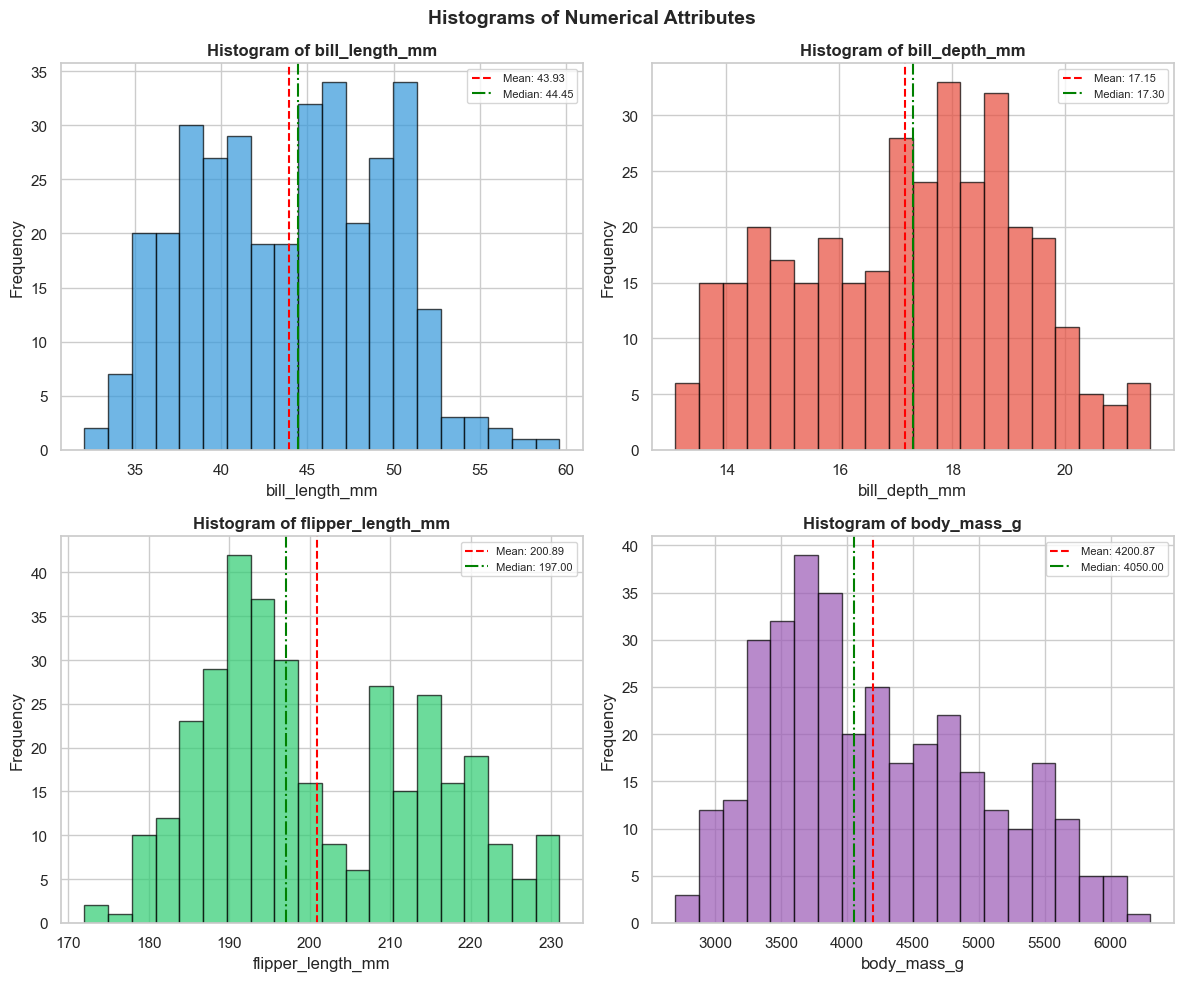

✅ Numerical Histograms Loaded


In [590]:
fig, axes = plt.subplots(2, 2, figsize=(12,10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=20, color=colors[i], edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Histogram of {col}', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', label=f'Mean: {df[col].mean():.2f}')
    axes[i].axvline(df[col].median(), color='green', linestyle='-.', label=f'Median: {df[col].median():.2f}')
    axes[i].legend(fontsize=8)
    
plt.suptitle("Histograms of Numerical Attributes", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("✅ Numerical Histograms Loaded")

### 3.2 Create box plots for all numerical attributes to identify outliers (use subplots, 2x2 grid)

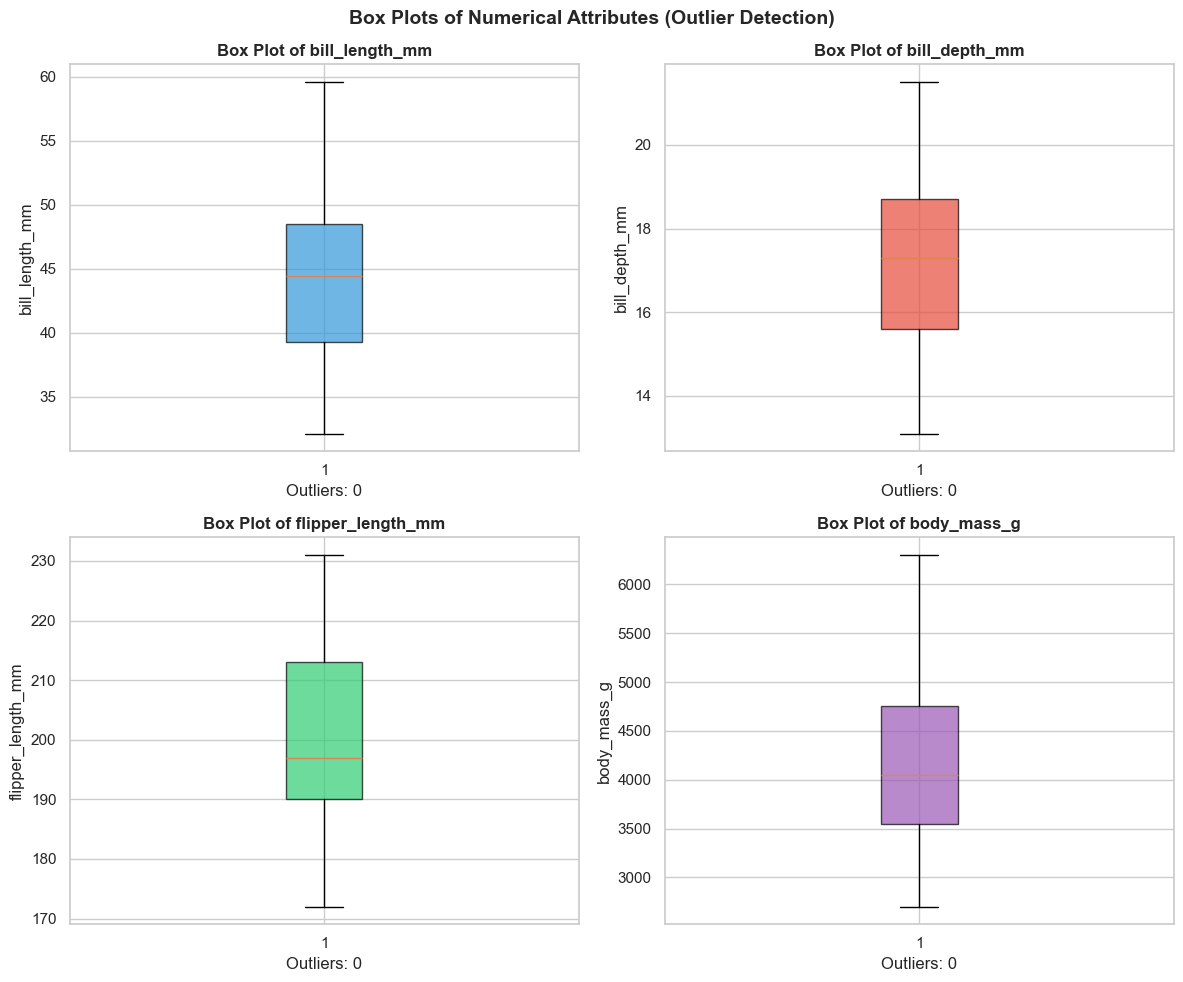

✅ Numerical Box Plots Loaded


In [588]:
fig, axes = plt.subplots(2, 2, figsize=(12,10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    bp = axes[i].boxplot(df[col], patch_artist=True)
    bp['boxes'][0].set_facecolor(colors[i])
    bp['boxes'][0].set_alpha(0.7)
    axes[i].set_title(f'Box Plot of {col}', fontweight='bold')
    axes[i].set_ylabel(col)
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)][col]
    axes[i].set_xlabel(f'Outliers: {len(outliers)}')

plt.suptitle('Box Plots of Numerical Attributes (Outlier Detection)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("✅ Numerical Box Plots Loaded")

### 3.3 Create bar charts for all categorical attributes showing frequency counts

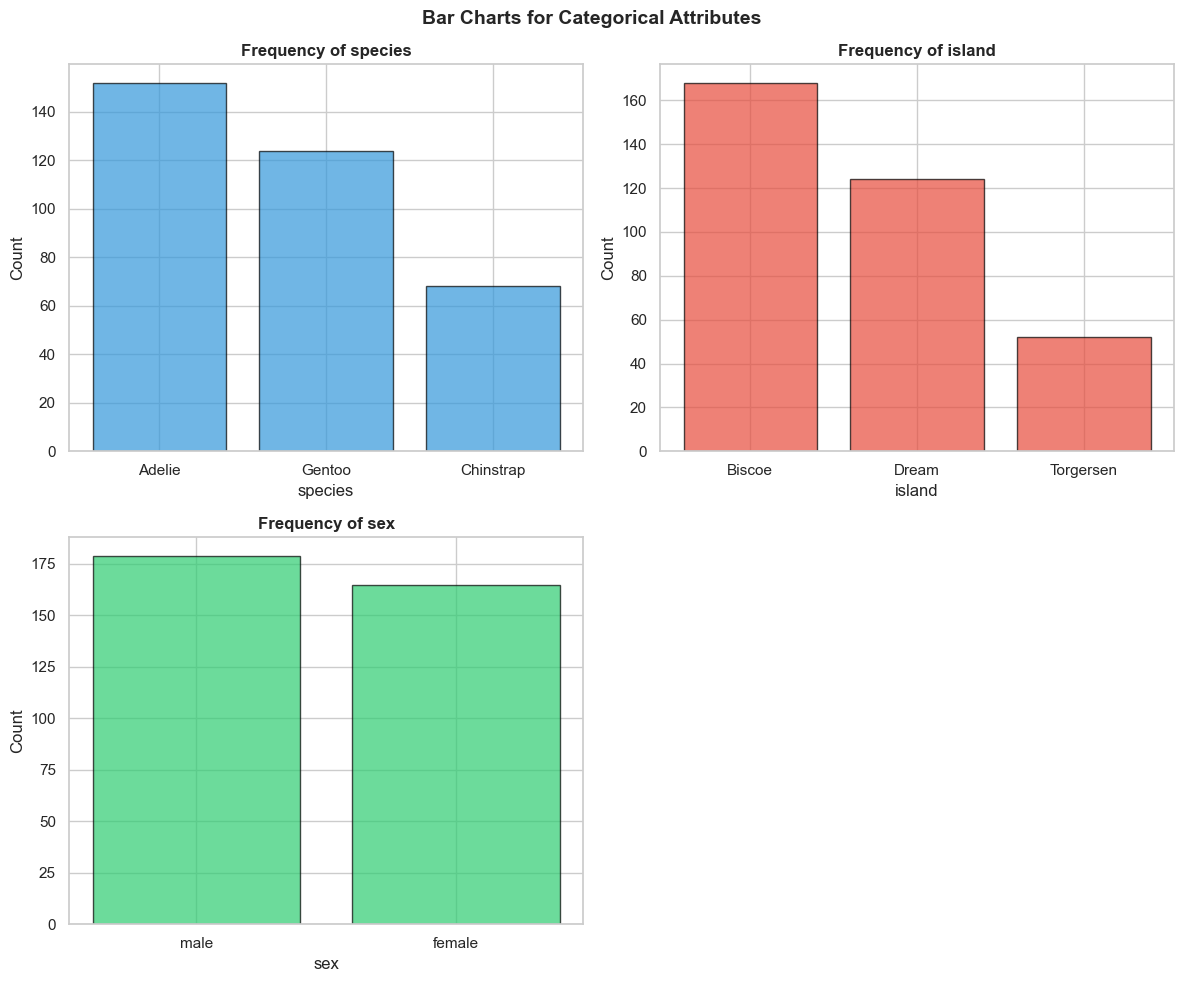

✅ Categorical Bar Charts Loaded


In [586]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    axes[i].bar(counts.index, counts.values, color=colors[i], edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Frequency of {col}', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

if len(cat_cols) == 3:
    # grab position of bottom-right
    pos_right = axes[3].get_position()

    # remove the empty 4th plot
    fig.delaxes(axes[3])

plt.suptitle('Bar Charts for Categorical Attributes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("✅ Categorical Bar Charts Loaded")

### 3.4 Create a pair plot (scatter plot matrix) to explore relationships between all numerical features, colored by species

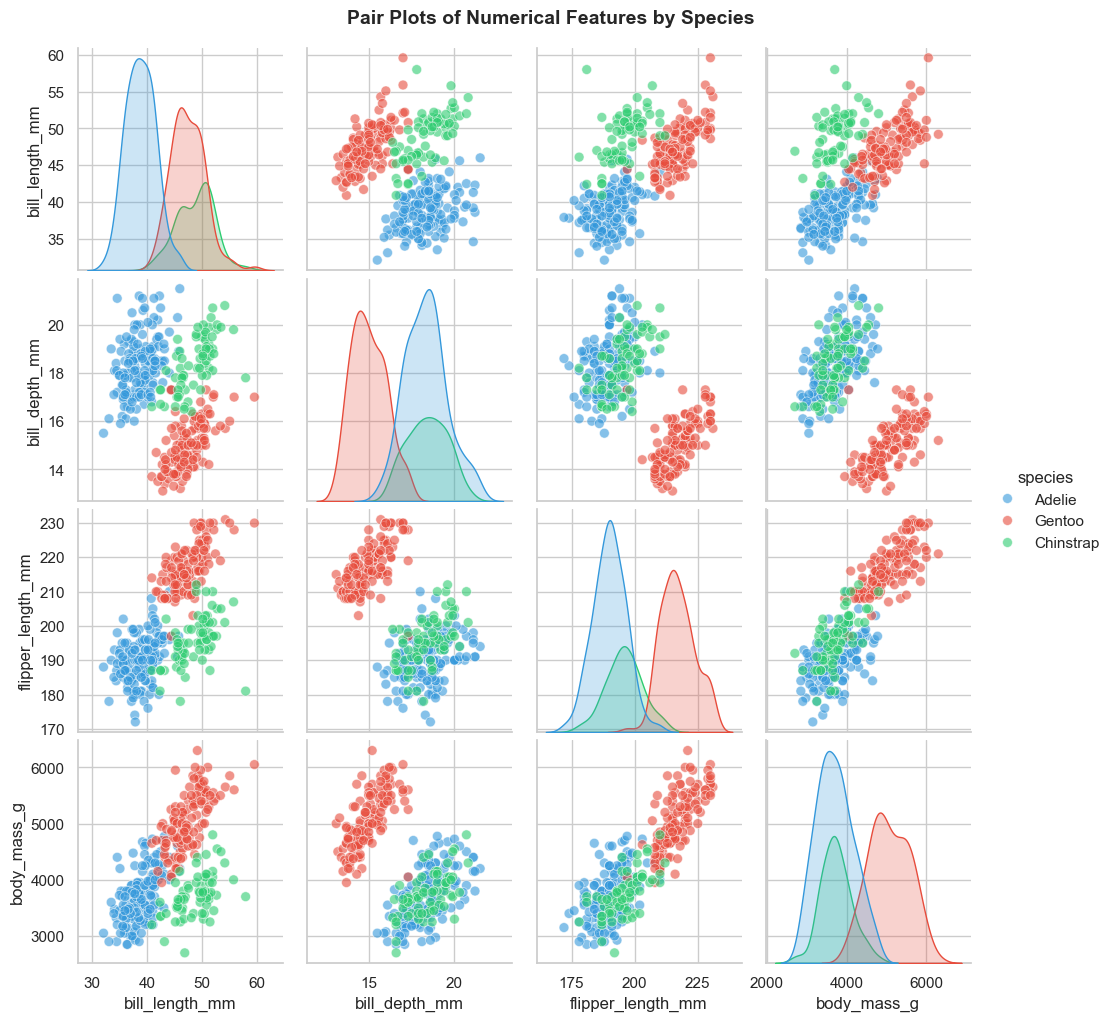

✅ Pair Plots Loaded


In [584]:
g = sns.pairplot(df[num_cols.tolist() + ['species']],
                 hue="species",
                 vars=num_cols,
                 palette={'Adelie': '#3498db', 'Gentoo': '#e74c3c', 'Chinstrap': '#2ecc71'},
                 diag_kind='kde',
                 plot_kws={'alpha': 0.6, 's': 50})
g.fig.suptitle('Pair Plots of Numerical Features by Species', y=1.02, fontsize=14, fontweight='bold')
plt.show()

print("✅ Pair Plots Loaded")

### 3.5 Create scatter plots for selected pairs of numerical attributes (bill_length_mm vs bill_depth_mm, flipper_length_mm vs body_mass_g) colored by species

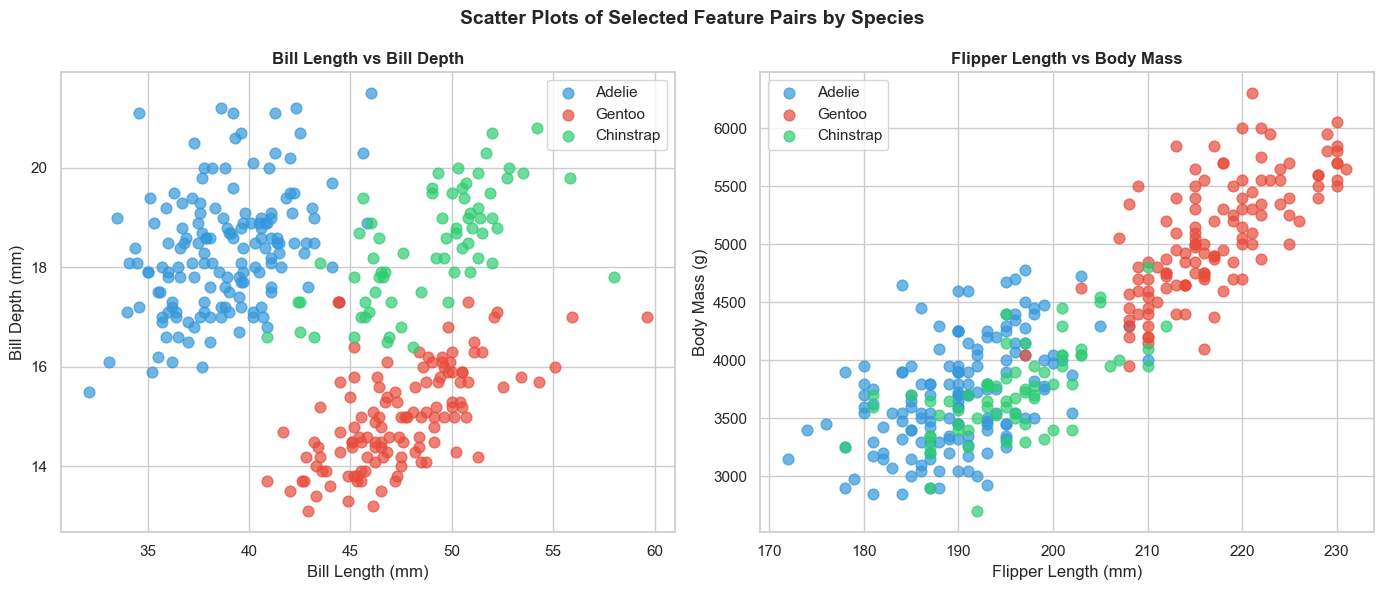

✅ Scatter Plots Loaded


In [582]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
species_colors = {'Adelie': '#3498db', 'Gentoo': '#e74c3c', 'Chinstrap': '#2ecc71'}

for species in df['species'].unique():
    subset = df[df['species'] == species]
    axes[0].scatter(
        subset['bill_length_mm'],
        subset['bill_depth_mm'],
        c=species_colors[species],
        label=species,
        alpha=0.7,
        s=60
    )

axes[0].set_xlabel('Bill Length (mm)')
axes[0].set_ylabel('Bill Depth (mm)')
axes[0].set_title('Bill Length vs Bill Depth', fontweight='bold')
axes[0].legend()

for species in df['species'].unique():
    subset = df[df['species'] == species]
    axes[1].scatter(
        subset['flipper_length_mm'],
        subset['body_mass_g'],
        c=species_colors[species],
        label=species,
        alpha=0.7,
        s=60
    )

axes[1].set_xlabel('Flipper Length (mm)')
axes[1].set_ylabel('Body Mass (g)')
axes[1].set_title('Flipper Length vs Body Mass', fontweight='bold')
axes[1].legend()

plt.suptitle('Scatter Plots of Selected Feature Pairs by Species', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("✅ Scatter Plots Loaded")

## Section 4: Core Statistical Computations (Matrix + Probability + Covariance/Correlation)

### 4.1 Multivariate mean vector

In [492]:
D = df[num_cols].values
n, p = D.shape

print("a) Compute the mean vector μ for all numerical attributes")
mean_vector = np.mean(D, axis=0)

print("\n✅ Mean Vectors Calculated")

print("\nb) Display it as a column vector")
print("     ┌           ┐")
for i, (col, val) in enumerate(zip(num_cols, mean_vector)):
    print(f"μ =  │ {val:9.4f} │  ← {col}")
print("     └           ┘")

print("\n✅ Mean Vectors Displayed")

a) Compute the mean vector μ for all numerical attributes

✅ Mean Vectors Calculated

b) Display it as a column vector
     ┌           ┐
μ =  │   43.9250 │  ← bill_length_mm
μ =  │   17.1520 │  ← bill_depth_mm
μ =  │  200.8924 │  ← flipper_length_mm
μ =  │ 4200.8721 │  ← body_mass_g
     └           ┘

✅ Mean Vectors Displayed


### 4.2 Sample covariance matrix — inner product method

In [495]:
D_centered = D - mean_vector

print("a) Center the numerical data matrix")
cov_matrix = (D_centered.T @ D_centered) / (n-1)

print("\n✅ Numerical Data Matrix Centered")

print("\nb) Compute the Covariance Matrix")
cov_df = pd.DataFrame(cov_matrix, index=num_cols, columns=num_cols)
print(cov_df.round(4))

cov_numpy = np.cov(D, rowvar=False)
print(f"\nVerification with np.cov(): Max difference = {np.max(np.abs(cov_matrix - cov_numpy)):.2e}")

print("\n✅ Covariance Matrix Calculated and Verified")

a) Center the numerical data matrix

✅ Numerical Data Matrix Centered

b) Compute the Covariance Matrix
                   bill_length_mm  bill_depth_mm  flipper_length_mm  \
bill_length_mm            29.6349        -2.5190            50.0700   
bill_depth_mm             -2.5190         3.8772           -16.1218   
flipper_length_mm         50.0700       -16.1218           196.6677   
body_mass_g             2589.9344      -743.1432          9770.5751   

                   body_mass_g  
bill_length_mm       2589.9344  
bill_depth_mm        -743.1432  
flipper_length_mm    9770.5751  
body_mass_g        639514.5434  

Verification with np.cov(): Max difference = 7.11e-15

✅ Covariance Matrix Calculated and Verified


### 4.3  correlation between two attributes

In [498]:
print("a) Compute Pearson correlation between bill_length_mm and bill_depth_mm")

corr_matrix = np.corrcoef(df['bill_length_mm'], df['bill_depth_mm'])
corr = corr_matrix[0,1]
print(f"Pearson Correlation: {corr:.4f}")

print("\n✅ Pearson Correlation Calculated")

a) Compute Pearson correlation between bill_length_mm and bill_depth_mm
Pearson Correlation: -0.2350

✅ Pearson Correlation Calculated


#### b) Interpret strength + direction (1-3 sentences)

There is a weak negative correlation between bill length and bill depth. While this could indicate that penguins with longer bills tend to have shallower/thinner bills. However, since the relationship is not strong, this indicates considerable variabion among species.

### 4.4 Correlation via cosine of the angle (centered vectors)

In [502]:
print("a) Compute correlation using cosine similarity of centered vectors")
x1_centered = df['bill_length_mm'].values - df['bill_length_mm'].mean()
x2_centered = df['bill_depth_mm'].values - df['bill_depth_mm'].mean()

dot_product = np.dot(x1_centered, x2_centered)
norm1 = np.linalg.norm(x1_centered)
norm2 = np.linalg.norm(x2_centered)
cosine_corr = dot_product / (norm1 * norm2)

print("Formula: r = (x̃₁ · x̃₂) / (||x̃₁|| × ||x̃₂||)")
print(f"\nComputation:")
print(f"  x̃₁ · x̃₂ = {dot_product:.4f}")
print(f"  ||x̃₁|| = {norm1:.4f}")
print(f"  ||x̃₂|| = {norm2:.4f}")
print(f"\n  r = {dot_product:.4f} / ({norm1:.4f} × {norm2:.4f}) = {cosine_corr:.4f}")

print("\n✅ Cosine Correlation Calculated")

print("\nb) Confirm it matches with 4.3  (within numerical tolerance)")
print(f"\nCorrelation from 4.3 vs Correlation from 4.4: 4.3-4.4 = {corr - cosine_corr}")

print("\n✅ Correlations Checked")

a) Compute correlation using cosine similarity of centered vectors
Formula: r = (x̃₁ · x̃₂) / (||x̃₁|| × ||x̃₂||)

Computation:
  x̃₁ · x̃₂ = -864.0175
  ||x̃₁|| = 100.8204
  ||x̃₂|| = 36.4675

  r = -864.0175 / (100.8204 × 36.4675) = -0.2350

✅ Cosine Correlation Calculated

b) Confirm it matches with 4.3  (within numerical tolerance)

Correlation from 4.3 vs Correlation from 4.4: 4.3-4.4 = 0.0

✅ Correlations Checked


### 4.5 Covariance of  categorical attributes

a) Compute covariance matrix of the categorical variables

✅ Covariance Matrix Calculated

b) Visualize with a heatmap


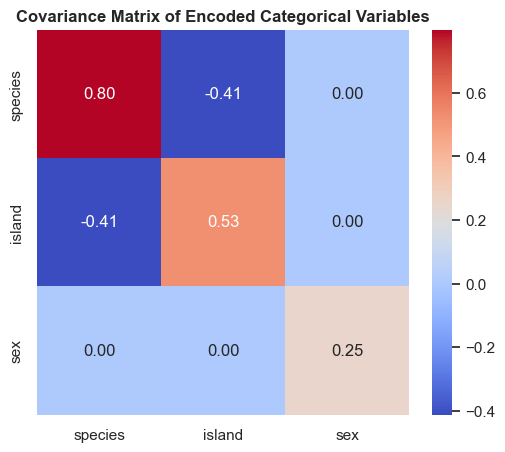

✅ Heatmap Loaded


In [580]:
print("a) Compute covariance matrix of the categorical variables")
# Encoding categories as numbers
df_encoded = df.copy()
for col in cat_cols:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes

# Computing Covariance Matrix
cov_cat = df_encoded[cat_cols].cov()

print("\n✅ Covariance Matrix Calculated")

print("\nb) Visualize with a heatmap")
# Plotting Heatmap
plt.figure(figsize=(6,5))
sns.heatmap(cov_cat, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Covariance Matrix of Encoded Categorical Variables", fontweight='bold')
plt.show()

print("✅ Heatmap Loaded")

> This covariance matrix has a limited and fragile interpretation of the data because the number that each category is assigned is arbitrary and has no inherent meaning to extract. 

### 4.6 Normal PDF fitting (one attribute)

a) Fit a Normal distribution to bill_length_mm (estimate μ, σ)

✅ μ and σ estimated

b) Plot histogram + fitted PDF overlay


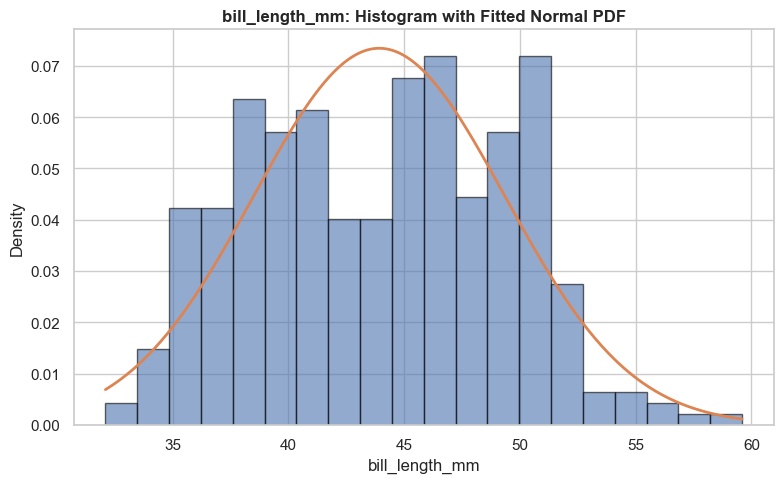

✅ Histogram Loaded

c) Report fitted μ and σ
Fitted μ (mean) = 43.9250
Fitted σ (std)  = 5.4359

✅ Fitted μ and σ Reported


In [518]:
print("a) Fit a Normal distribution to bill_length_mm (estimate μ, σ)")
x = df["bill_length_mm"]

mu_hat = x.mean()
sigma_hat = x.std(ddof=0)

print("\n✅ μ and σ estimated")

print("\nb) Plot histogram + fitted PDF overlay")
plt.figure(figsize=(8, 5))
plt.hist(x, bins=20, density=True, alpha=0.6, edgecolor="black")

# PDF curve
x_grid = np.linspace(x.min(), x.max(), 400)
pdf = (1/(sigma_hat*np.sqrt(2*np.pi))) * np.exp(-0.5*((x_grid - mu_hat)/sigma_hat)**2)

plt.plot(x_grid, pdf, linewidth=2)
plt.title("bill_length_mm: Histogram with Fitted Normal PDF", fontweight="bold")
plt.xlabel("bill_length_mm")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

print("✅ Histogram Loaded")

print("\nc) Report fitted μ and σ")

print(f"Fitted μ (mean) = {mu_hat:.4f}")
print(f"Fitted σ (std)  = {sigma_hat:.4f}")

print("\n✅ Fitted μ and σ Reported")


### 4.7 Variance analysis

a) Compute variance for each numerical attribute
bill_length_mm: 29.6349
bill_depth_mm: 3.8772
flipper_length_mm: 196.6677
body_mass_g: 639514.5434

✅ Variance Computed

b) Identify largest variance attribute and smallest variance attribute

Largest variance attribute:  body_mass_g (639514.5434)
Smallest variance attribute: bill_depth_mm (3.8772)

✅ Largest and Smallest Varience Identified

c) Bar chart of variances


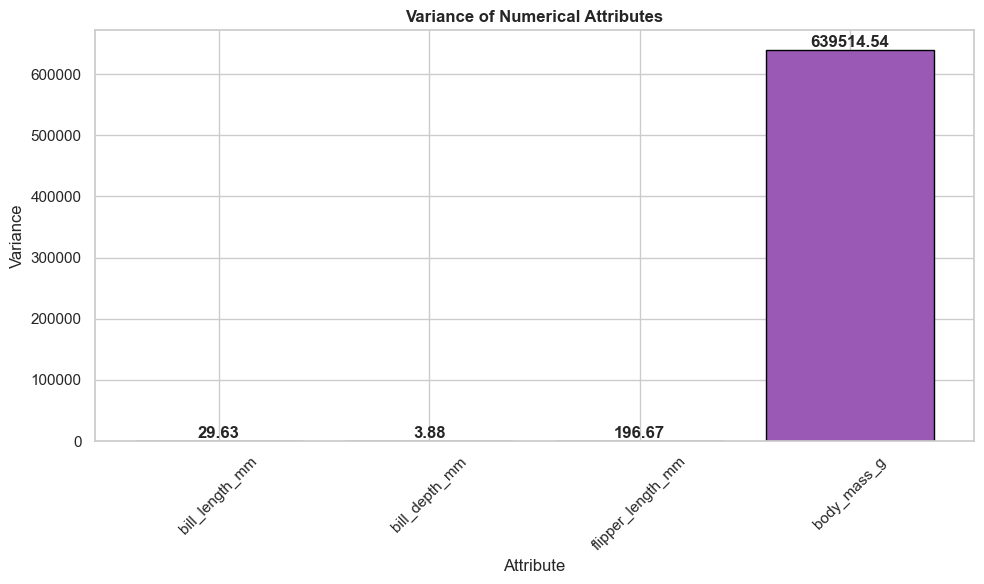

✅ Bar Charts Loaded


In [527]:
print("a) Compute variance for each numerical attribute")
variances = df[num_cols].var()

for col, var in variances.items():
    print(f"{col}: {var:.4f}")

print("\n✅ Variance Computed")

print("\nb) Identify largest variance attribute and smallest variance attribute")
largest_attr = variances.idxmax()
smallest_attr = variances.idxmin()

print(f"\nLargest variance attribute:  {largest_attr} ({variances.max():.4f})")
print(f"Smallest variance attribute: {smallest_attr} ({variances.min():.4f})")

print("\n✅ Largest and Smallest Varience Identified")

print("\nc) Bar chart of variances")
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(
    variances.index,
    variances.values,
    color=colors,
    edgecolor='black'
)

ax.set_xlabel('Attribute')
ax.set_ylabel('Variance')
ax.set_title('Variance of Numerical Attributes', fontweight='bold')
ax.tick_params(axis='x', rotation=45)

# Add value labels above bars
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.2f}',
        ha='center',
        va='bottom',
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

print("✅ Bar Charts Loaded")


### 4.8 Covariance extremes

In [559]:
print("a) From the covariance matrix (numerical attributes only) find the pair with largest covariance and find the pair with smallest covariance (most negative or closest to zero — clarify which you use)\n")
cov_pairs = []
for i in range(p):
    for j in range(i+1, p):
        print(f"     Cov({num_cols[i]}, {num_cols[j]}): {cov_matrix[i,j]:.4f}")
        cov_pairs.append((num_cols[i], num_cols[j], cov_matrix[i,j]))

cov_pairs_sorted = sorted(cov_pairs, key=lambda x: x[2], reverse=True)
max_pair = cov_pairs_sorted[0]
min_pair = cov_pairs_sorted[-1]

print(f"\nLargest covariance: {max_pair[0]} & {max_pair[1]} = {max_pair[2]:.4f}")
print(f"Smallest covariance: {min_pair[0]} & {min_pair[1]} = {min_pair[2]:.4f}")

print("\n✅ Largest and Smallest Identified")

a) From the covariance matrix (numerical attributes only) find the pair with largest covariance and find the pair with smallest covariance (most negative or closest to zero — clarify which you use)

     Cov(bill_length_mm, bill_depth_mm): -2.5190
     Cov(bill_length_mm, flipper_length_mm): 50.0700
     Cov(bill_length_mm, body_mass_g): 2589.9344
     Cov(bill_depth_mm, flipper_length_mm): -16.1218
     Cov(bill_depth_mm, body_mass_g): -743.1432
     Cov(flipper_length_mm, body_mass_g): 9770.5751

Largest covariance: flipper_length_mm & body_mass_g = 9770.5751
Smallest covariance: bill_depth_mm & body_mass_g = -743.1432

✅ Largest and Smallest Identified


#### b) Provide a brief interpretation for each pair
##### Largest
The largest covariance occured between flipper_length_mm and body_mass_g with a value of 9770.5751, indicating a strong positive linear relationship. This means that penguins with longer flippers will tend to have a greater body mass.

##### Smallest
The most negative covariance occured between bill_depth_mm and bpdu_mass_g with a value of -743.1432, indicating a slight inverse linear relationship. While this could mean that penguins with greater body mass will tend to have slightly shallower bills, however because the magnitude is much smaller than the largest, this relationship is rather weak

## Section 5: Scaling Methods Analysis

### 5.1 Standardization (Z-score)

a) Report mean/std before vs after (should be ~0 and ~1)
Formula: z = (x - μ) / σ

Before Standardization:
  Mean: [  43.925    17.152   200.8924 4200.8721]
  Std:  [  5.4438   1.9691  14.0238 799.6965]

After Standardization:
  Mean: [-0.  0.  0.  0.] (should be ~0)
  Std:  [1.0015 1.0015 1.0015 1.0015] (should be ~1)

✅ Both Mean and STD Calculated

b) Side-by-side box plots: original vs standardized (all numerical features)


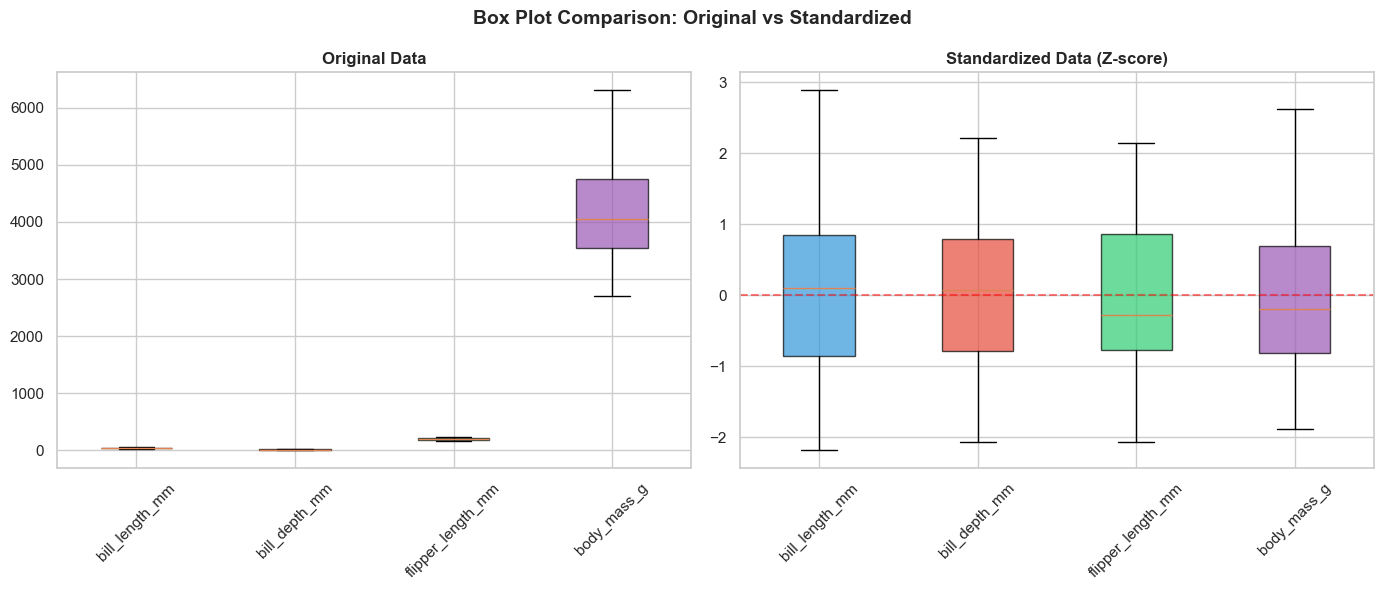

✅ Box Plots Loaded


In [578]:
print("a) Report mean/std before vs after (should be ~0 and ~1)")

X_orig = df[num_cols].copy()

scaler_std = StandardScaler()
X_standardized = pd.DataFrame(scaler_std.fit_transform(X_orig), columns=num_cols)

print("Formula: z = (x - μ) / σ")
print("\nBefore Standardization:")
print(f"  Mean: {X_orig.mean().values.round(4)}")
print(f"  Std:  {X_orig.std().values.round(4)}")

print("\nAfter Standardization:")
print(f"  Mean: {X_standardized.mean().values.round(4)} (should be ~0)")
print(f"  Std:  {X_standardized.std().values.round(4)} (should be ~1)")

print("\n✅ Both Mean and STD Calculated")

print("\nb) Side-by-side box plots: original vs standardized (all numerical features)")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

bp1 = axes[0].boxplot([X_orig[col] for col in num_cols], patch_artist=True, tick_labels=num_cols)
for patch, color in zip(bp1['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0].set_title('Original Data', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

bp2 = axes[1].boxplot([X_standardized[col] for col in num_cols], patch_artist=True, tick_labels=num_cols)
for patch, color in zip(bp2['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_title('Standardized Data (Z-score)', fontweight='bold')
axes[1].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Box Plot Comparison: Original vs Standardized', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("✅ Box Plots Loaded")

### 5.2 Min–Max normalization

a) Report min/max before vs after (should be in [0,1])
Formula: x' = (x - min) / (max - min)

Before Min-Max Normalization:
  Min: [  32.1   13.1  172.  2700. ]
  Max: [  59.6   21.5  231.  6300. ]

After Min-Max Normalization:
  Min: [0. 0. 0. 0.] (should be 0)
  Max: [1. 1. 1. 1.] (should be 1)

✅ Both Min and Max Calculated

b) Compare distributions using histograms (original vs min–max)


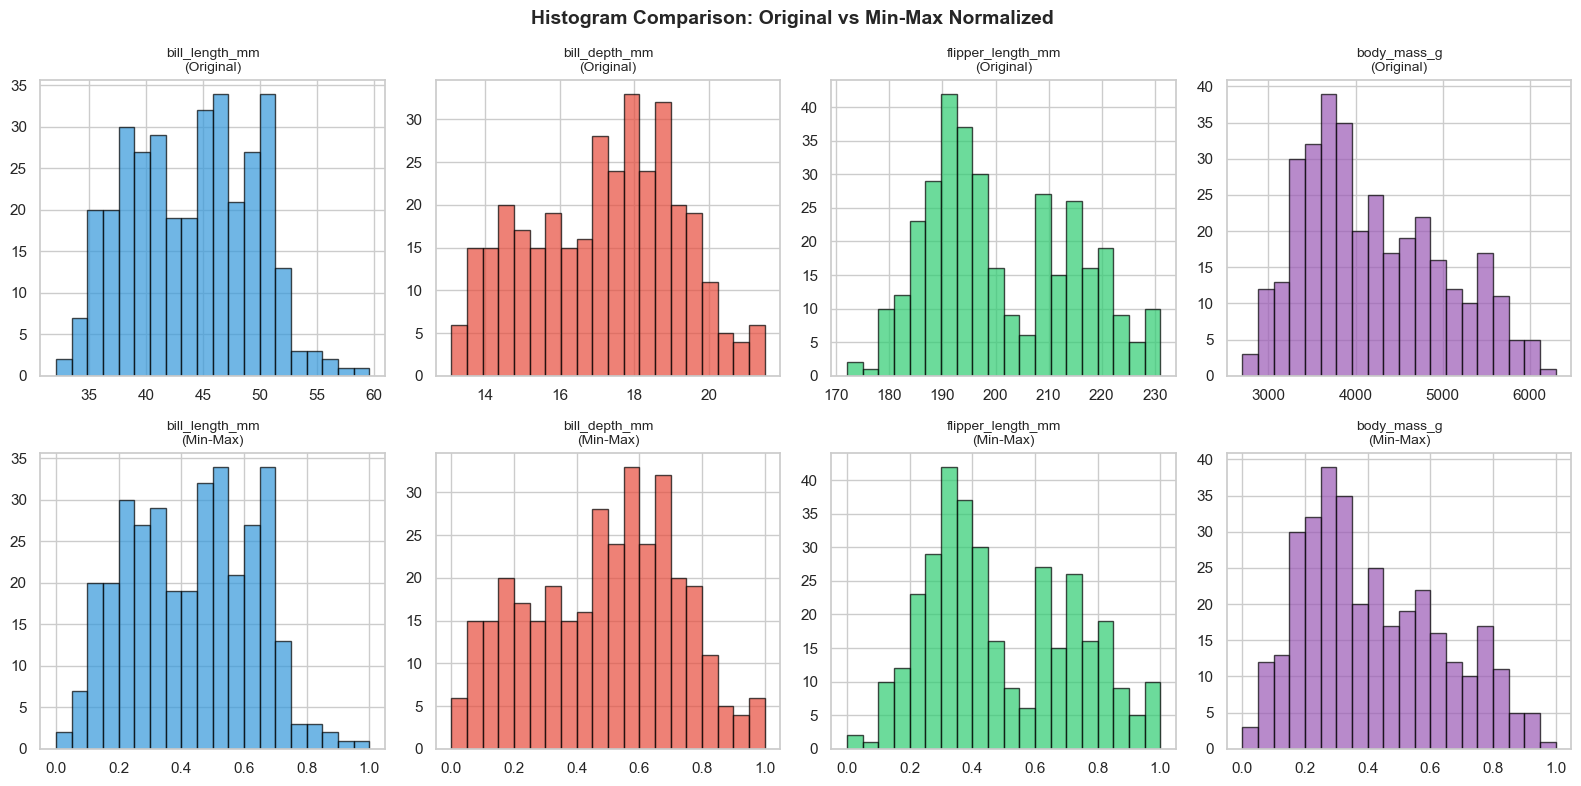

✅ Histogram Loaded


In [596]:
print("a) Report min/max before vs after (should be in [0,1])")

scaler_minmax = MinMaxScaler()
X_minmax = pd.DataFrame(scaler_minmax.fit_transform(X_orig), columns=num_cols)

print("Formula: x' = (x - min) / (max - min)")
print("\nBefore Min-Max Normalization:")
print(f"  Min: {X_orig.min().values.round(4)}")
print(f"  Max: {X_orig.max().values.round(4)}")

print("\nAfter Min-Max Normalization:")
print(f"  Min: {X_minmax.min().values.round(4)} (should be 0)")
print(f"  Max: {X_minmax.max().values.round(4)} (should be 1)")

print("\n✅ Both Min and Max Calculated")

print("\nb) Compare distributions using histograms (original vs min–max)")

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, col in enumerate(num_cols):
    axes[0, i].hist(X_orig[col], bins=20, color=colors[i], edgecolor='black', alpha=0.7)
    axes[0, i].set_title(f'{col}\n(Original)', fontsize=10)
    axes[1, i].hist(X_minmax[col], bins=20, color=colors[i], edgecolor='black', alpha=0.7)
    axes[1, i].set_title(f'{col}\n(Min-Max)', fontsize=10)

plt.suptitle('Histogram Comparison: Original vs Min-Max Normalized', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("✅ Histogram Loaded")

### 5.3 Robust scaling

a) Report median and IQR before vs after (summary table)
Formula: x' = (x - median) / IQR

Summary Table (Median and IQR):
                   Original_Median  Original_IQR  Robust_Median  Robust_IQR
bill_length_mm               44.45         9.225            0.0         1.0
bill_depth_mm                17.30         3.100            0.0         1.0
flipper_length_mm           197.00        23.000            0.0         1.0
body_mass_g                4050.00      1200.000            0.0         1.0

✅ Summary Table Loaded

b) Box plots comparing original, standardized, and robust scaled


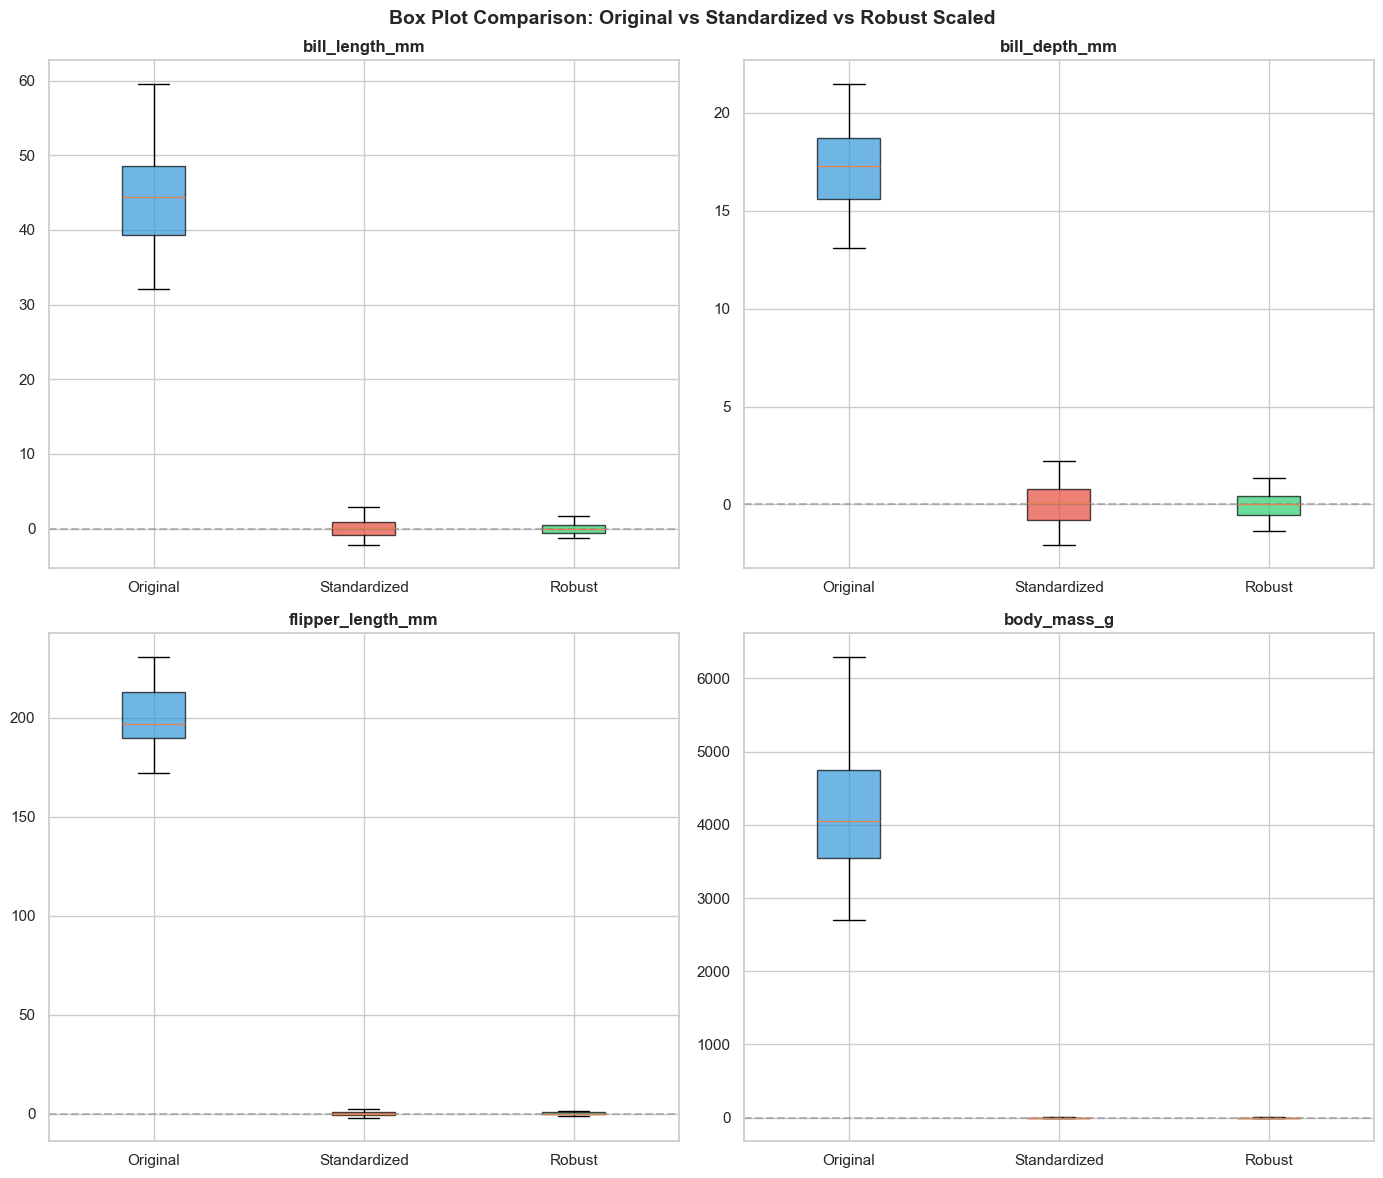

✅ Box Plots Loaded


In [600]:
print("a) Report median and IQR before vs after (summary table)")

scaler_robust = RobustScaler()
X_robust = pd.DataFrame(scaler_robust.fit_transform(X_orig), columns=num_cols)

print("Formula: x' = (x - median) / IQR")
print("\nSummary Table (Median and IQR):")
summary_table = pd.DataFrame({
    'Original_Median': X_orig.median(),
    'Original_IQR': X_orig.quantile(0.75) - X_orig.quantile(0.25),
    'Robust_Median': X_robust.median(),
    'Robust_IQR': X_robust.quantile(0.75) - X_robust.quantile(0.25)
})
print(summary_table.round(4))

print("\n✅ Summary Table Loaded")

print("\nb) Box plots comparing original, standardized, and robust scaled")

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    data_to_plot = [X_orig[col], X_standardized[col], X_robust[col]]
    bp = axes[i].boxplot(data_to_plot, patch_artist=True, tick_labels=['Original', 'Standardized', 'Robust'])
    for patch, color in zip(bp['boxes'], ['#3498db', '#e74c3c', '#2ecc71']):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    axes[i].set_title(f'{col}', fontweight='bold')
    axes[i].axhline(y=0, color='gray', linestyle='--', alpha=0.5)

plt.suptitle('Box Plot Comparison: Original vs Standardized vs Robust Scaled', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("✅ Box Plots Loaded")

### 5.4 Does scaling change correlation?

a) Compute correlation matrices for original, standardized, and min–max

✅ Correlation Matrices Computed

b) Show heatmaps for each


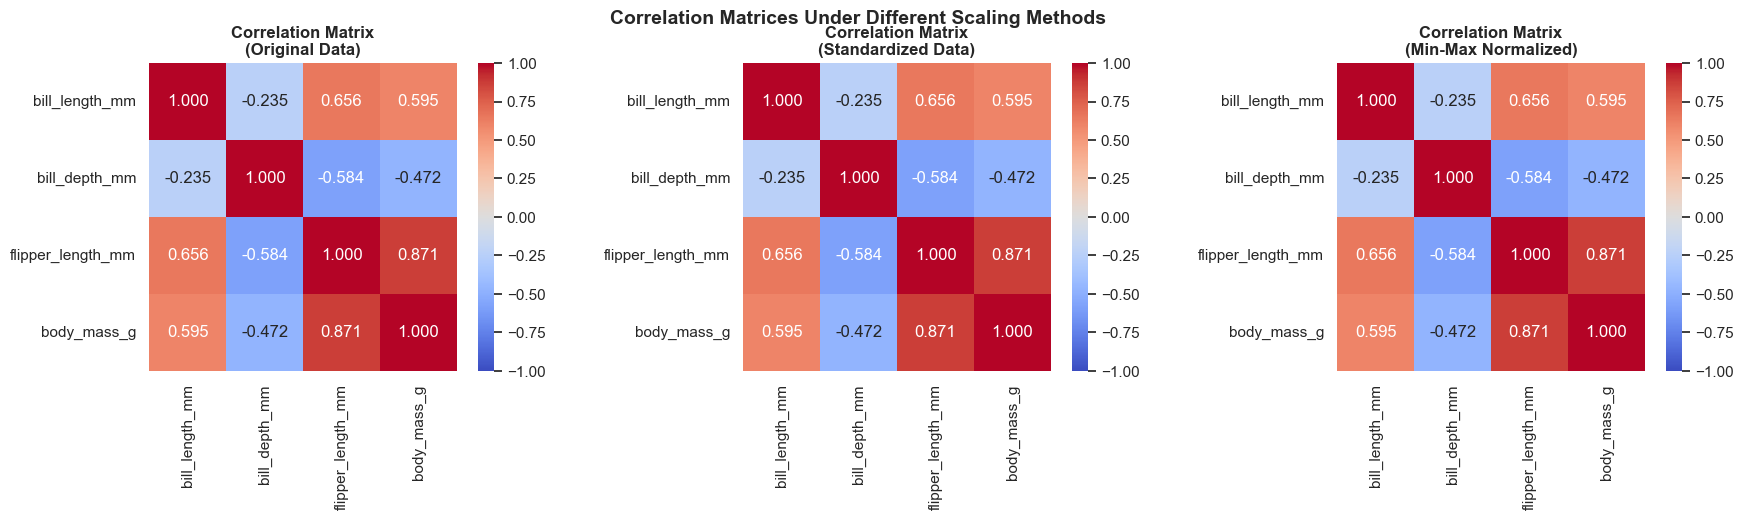

✅ Heatmaps Loaded

Verification for Correlations not changing
  Max diff (Original vs Standardized): 3.77e-15
  Max diff (Original vs Min-Max):      3.66e-15


In [608]:
print("a) Compute correlation matrices for original, standardized, and min–max")
corr_orig = X_orig.corr()
corr_std = X_standardized.corr()
corr_minmax = X_minmax.corr()

print("\n✅ Correlation Matrices Computed")

print("\nb) Show heatmaps for each")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
matrices = [corr_orig, corr_std, corr_minmax]
titles = ['Original Data', 'Standardized Data', 'Min-Max Normalized']

for ax, corr_mat, title in zip(axes, matrices, titles):
    sns.heatmap(corr_mat, annot=True, fmt='.3f', cmap='coolwarm', center=0, vmin=-1, vmax=1, ax=ax, square=True)
    ax.set_title(f'Correlation Matrix\n({title})', fontweight='bold')

plt.suptitle('Correlation Matrices Under Different Scaling Methods', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("✅ Heatmaps Loaded")

print(f"\nVerification for Correlations not changing")
print(f"  Max diff (Original vs Standardized): {np.max(np.abs(corr_orig - corr_std)):.2e}")
print(f"  Max diff (Original vs Min-Max):      {np.max(np.abs(corr_orig - corr_minmax)):.2e}")

#### c) Discuss (short): should correlation change or not, and why?
Correlation should not change as the linear transformation does not change the correlation coefficients

## Section 6: Correlation Matrix Analysis (Numerical Attributes)

1) Compute correlation matrix (rounded to 3 decimals)

Correlation Matrix (rounded to 3 decimals):
                   bill_length_mm  bill_depth_mm  flipper_length_mm  \
bill_length_mm              1.000         -0.235              0.656   
bill_depth_mm              -0.235          1.000             -0.584   
flipper_length_mm           0.656         -0.584              1.000   
body_mass_g                 0.595         -0.472              0.871   

                   body_mass_g  
bill_length_mm           0.595  
bill_depth_mm           -0.472  
flipper_length_mm        0.871  
body_mass_g              1.000  

✅ Correlation Matrix Computed

2) Heatmap with annotated correlation values


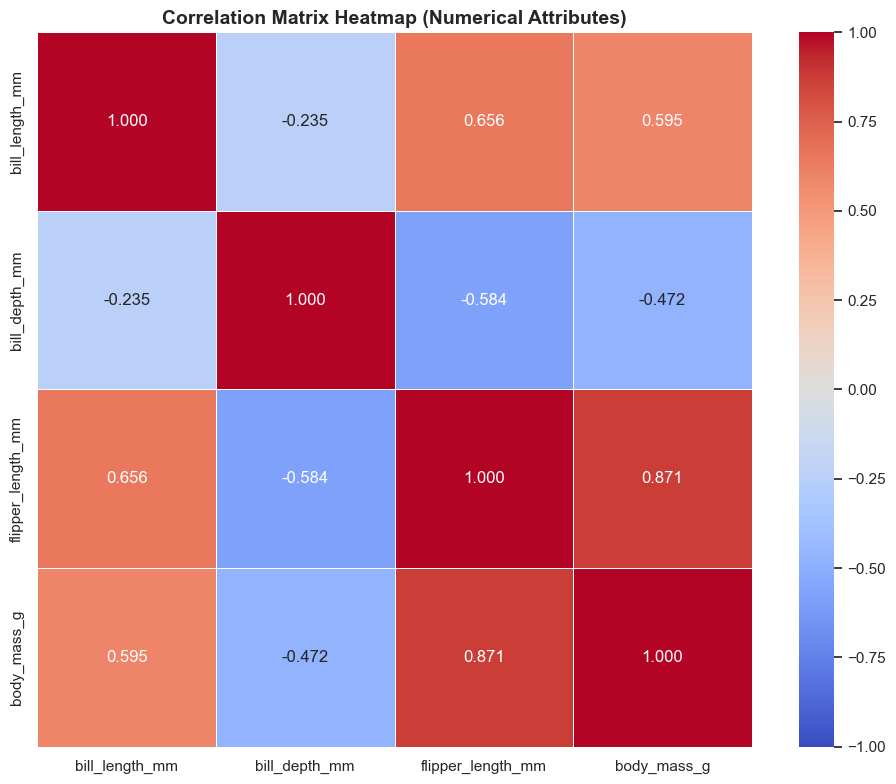

✅ Heatmap Loaded

3) Identify strongest positive correlation (excluding diagonal) and strongest negative correlation

Correlation Pairs (sorted):
                               Pair  Correlation
   flipper_length_mm vs body_mass_g        0.871
bill_length_mm vs flipper_length_mm        0.656
      bill_length_mm vs body_mass_g        0.595
    bill_length_mm vs bill_depth_mm       -0.235
       bill_depth_mm vs body_mass_g       -0.472
 bill_depth_mm vs flipper_length_mm       -0.584

Strongest Positive: flipper_length_mm vs body_mass_g (r = 0.871)
Strongest Negative: bill_depth_mm vs flipper_length_mm (r = -0.584)

✅ Strongest Positive and Negative Identified


In [614]:
print("1) Compute correlation matrix (rounded to 3 decimals)")

corr_matrix = df[num_cols].corr().round(3)
print("\nCorrelation Matrix (rounded to 3 decimals):")
print(corr_matrix)

print("\n✅ Correlation Matrix Computed")

print("\n2) Heatmap with annotated correlation values")

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            vmin=-1, vmax=1, ax=ax, square=True, linewidths=0.5)
ax.set_title('Correlation Matrix Heatmap (Numerical Attributes)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("✅ Heatmap Loaded")

print("\n3) Identify strongest positive correlation (excluding diagonal) and strongest negative correlation")

corr_values = []
for i in range(len(num_cols)):
    for j in range(i+1, len(num_cols)):
        corr_values.append({'Pair': f"{num_cols[i]} vs {num_cols[j]}", 'Correlation': corr_matrix.iloc[i, j]})

corr_pairs_df = pd.DataFrame(corr_values).sort_values('Correlation', ascending=False)
print("\nCorrelation Pairs (sorted):")
print(corr_pairs_df.to_string(index=False))

print(f"\nStrongest Positive: {corr_pairs_df.iloc[0]['Pair']} (r = {corr_pairs_df.iloc[0]['Correlation']:.3f})")
print(f"Strongest Negative: {corr_pairs_df.iloc[-1]['Pair']} (r = {corr_pairs_df.iloc[-1]['Correlation']:.3f})")

print("\n✅ Strongest Positive and Negative Identified")

## Section 7: Univariate Analysis 

### 7.1 Numerical attributes (for EACH numerical feature)

a) Compute mean, median, mode, std, variance, min, max, Q1, Q3, IQR, skewness, and kurtosis

Numerical Attributes Summary: 
                        Mean   Median    Mode       Std     Variance     Min  \
Attribute                                                                      
bill_length_mm       43.9250    44.45    41.1    5.4438      29.6349    32.1   
bill_depth_mm        17.1520    17.30    17.0    1.9691       3.8772    13.1   
flipper_length_mm   200.8924   197.00   190.0   14.0238     196.6677   172.0   
body_mass_g        4200.8721  4050.00  3800.0  799.6965  639514.5434  2700.0   

                      Max        Q1      Q3       IQR  Skewness  Kurtosis  
Attribute                                                                  
bill_length_mm       59.6    39.275    48.5     9.225    0.0516   -0.8638  
bill_depth_mm        21.5    15.600    18.7     3.100   -0.1452   -0.8944  
flipper_length_mm   231.0   190.000   213.0    23.000    0.3512   -0.9719  
body_mass_g    

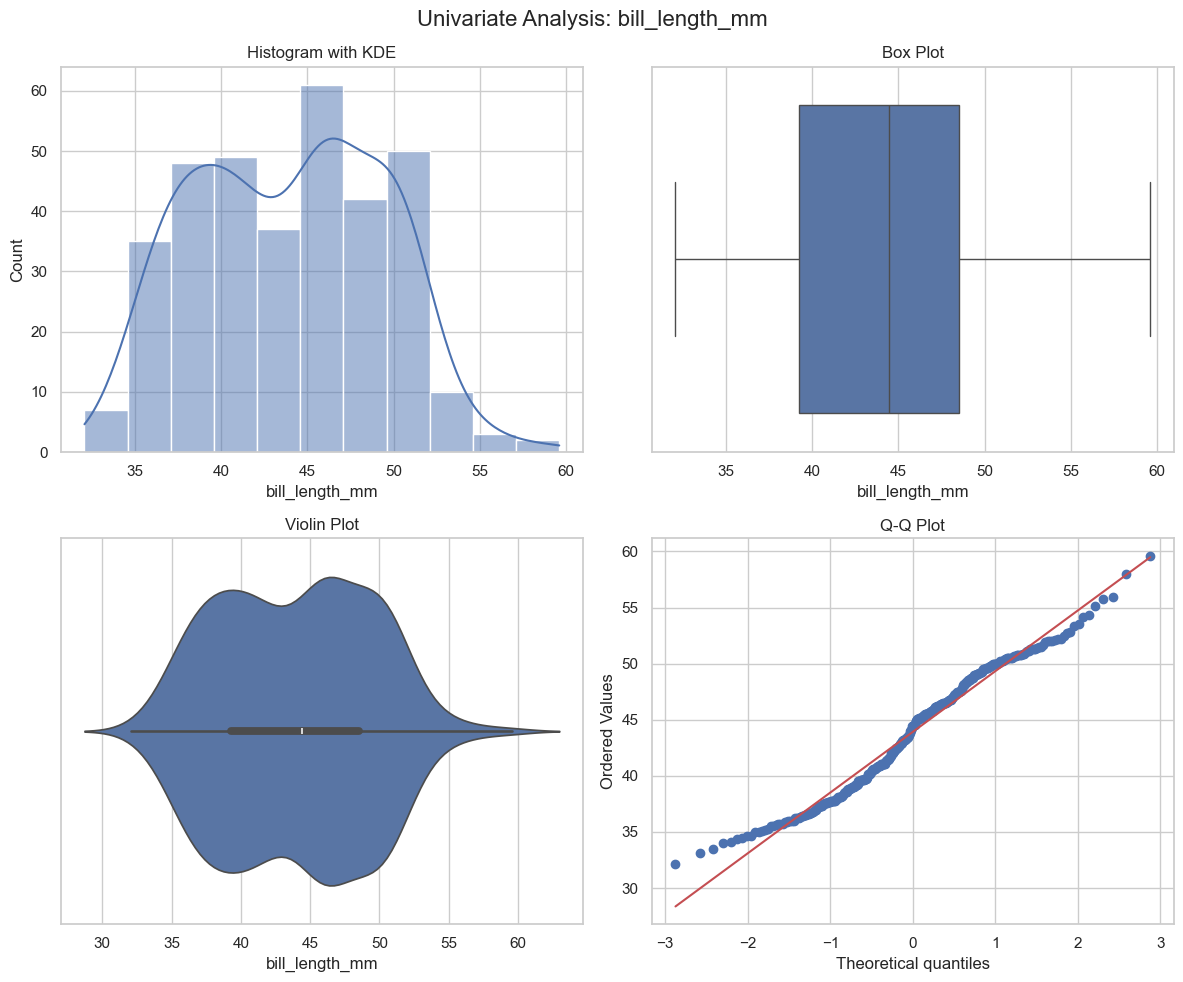

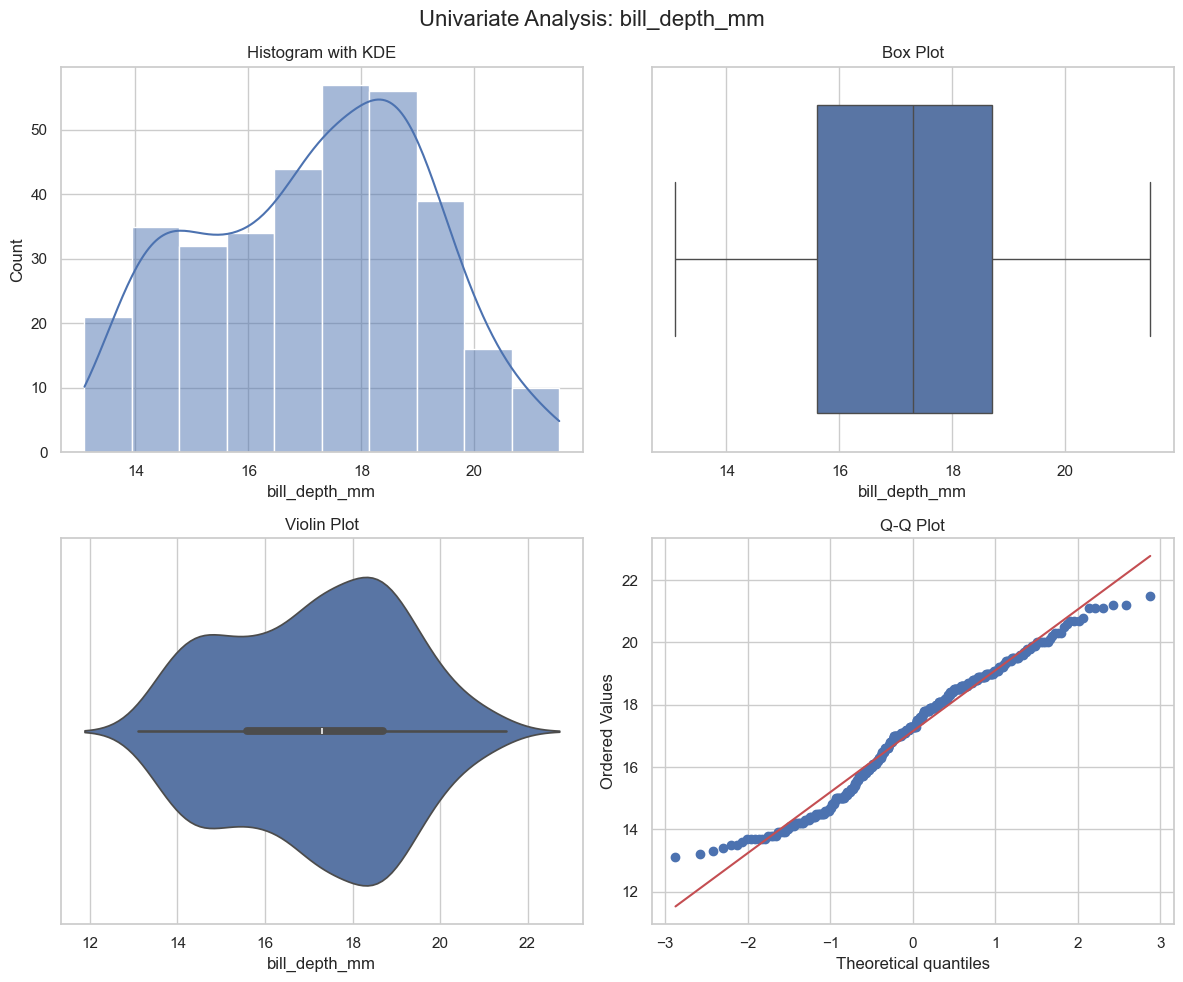

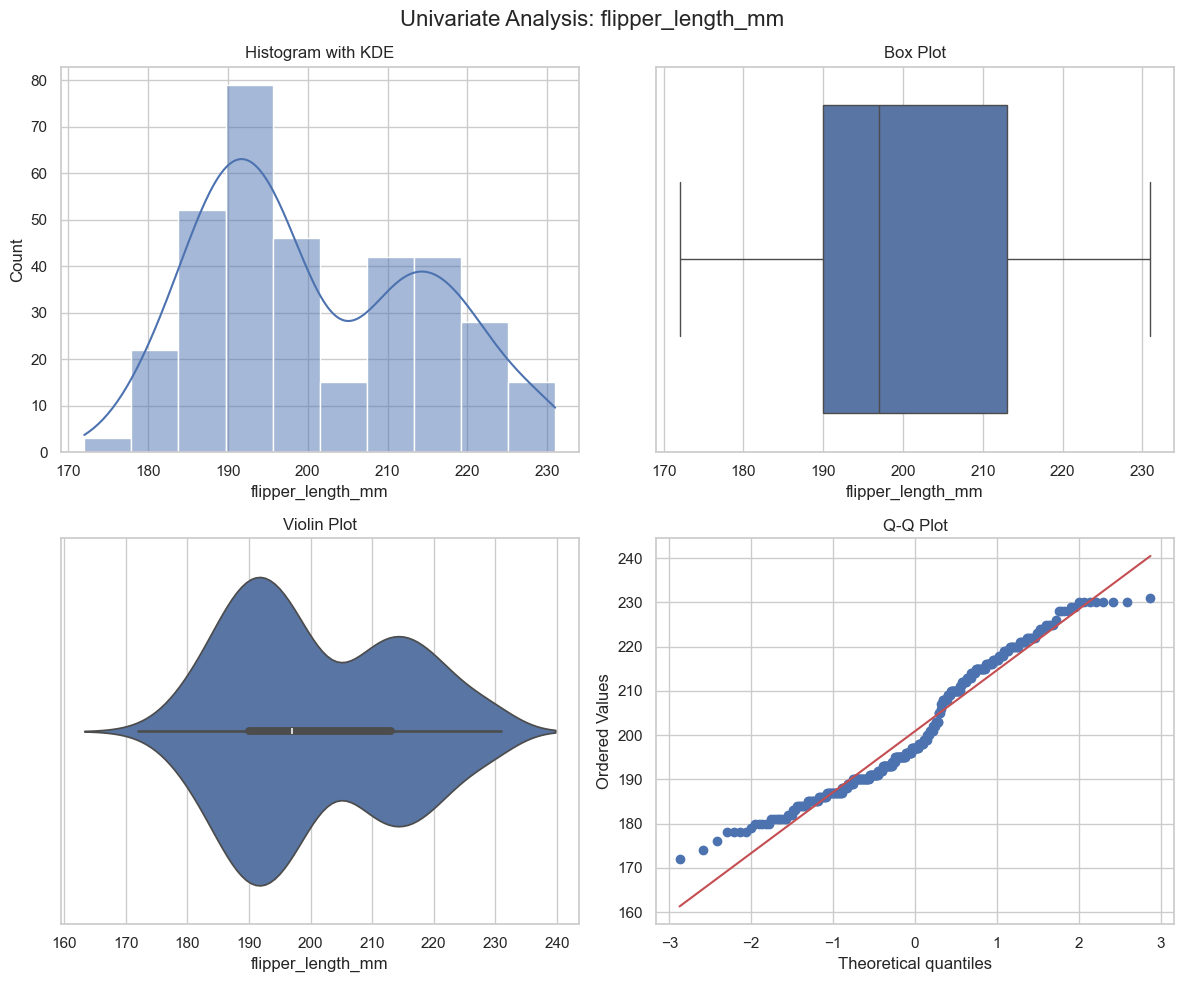

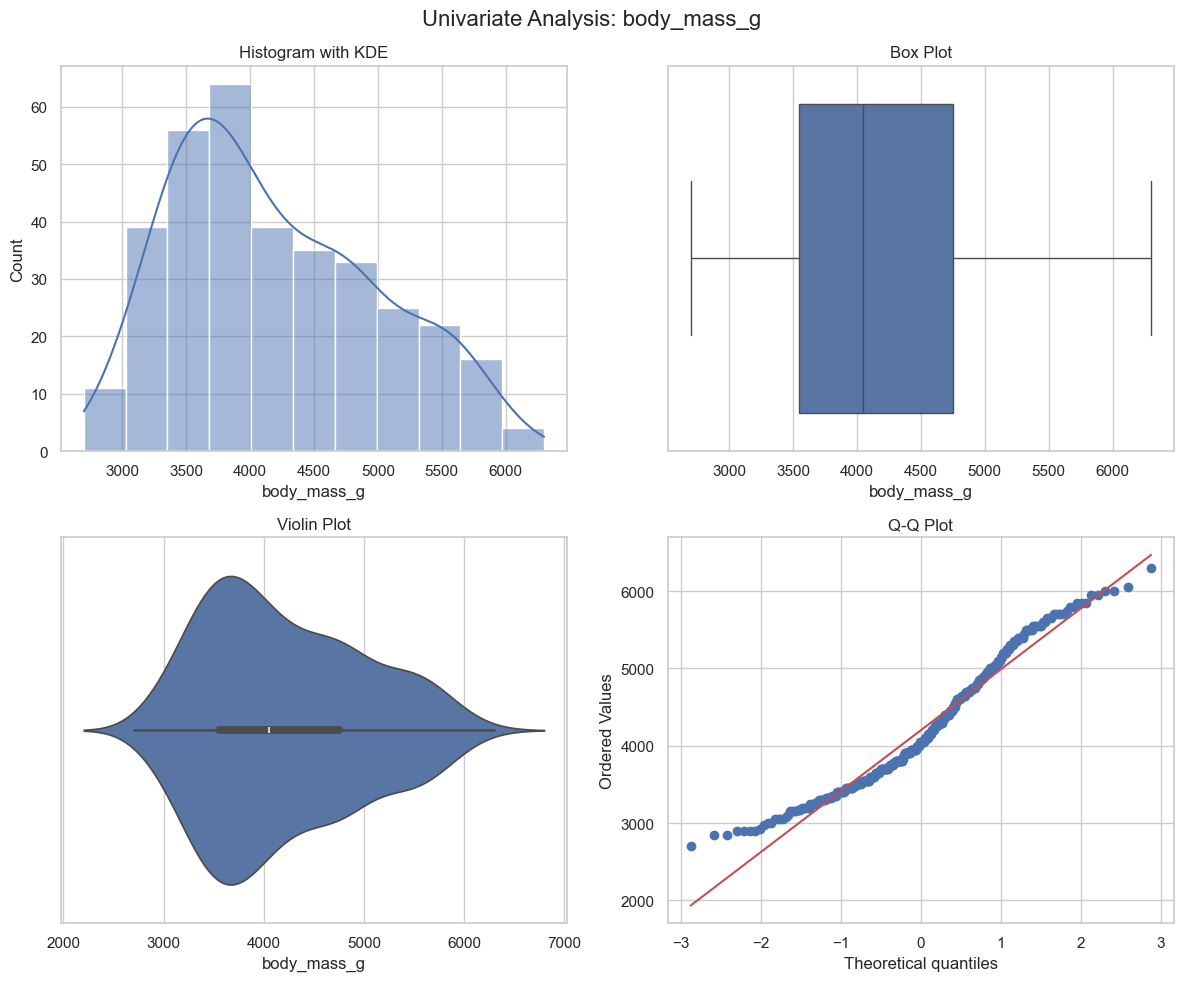

✅ Figures Loaded


In [624]:
print("a) Compute mean, median, mode, std, variance, min, max, Q1, Q3, IQR, skewness, and kurtosis")
univariate_stats = []
for col in num_cols:
    data = df[col]
    stats_dict = {
        'Attribute': col,
        'Mean': data.mean(),
        'Median': data.median(),
        'Mode': data.mode().iloc[0],
        'Std': data.std(),
        'Variance': data.var(),
        'Min': data.min(),
        'Max': data.max(),
        'Q1': data.quantile(0.25),
        'Q3': data.quantile(0.75),
        'IQR': data.quantile(0.75) - data.quantile(0.25),
        'Skewness': data.skew(),
        'Kurtosis': data.kurt()        
    }
    univariate_stats.append(stats_dict)

univariate_df = pd.DataFrame(univariate_stats).set_index('Attribute')
print(f"\nNumerical Attributes Summary: \n{univariate_df.round(4)}")

print("\n✅ Numerical Attributes for Each Feature Computed")

print("\nb) Create one 2×2 panel figure per attribute with Histogram (with KDE), Box plot, Violin plot, and Q–Q plot")

for col in num_cols:
    data = df[col].dropna()

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle(f'Univariate Analysis: {col}', fontsize=16)

    sns.histplot(data, kde=True, ax=axes[0, 0])
    axes[0, 0].set_title('Histogram with KDE')

    sns.boxplot(x=data, ax=axes[0, 1])
    axes[0, 1].set_title('Box Plot')

    sns.violinplot(x=data, ax=axes[1, 0])
    axes[1, 0].set_title('Violin Plot')

    stats.probplot(data, dist="norm", plot=axes[1, 1])
    axes[1, 1].set_title('Q-Q Plot')

    plt.tight_layout()
    plt.show()

print("✅ Figures Loaded")

### 7.2 Categorical attributes (for EACH categorical feature)

a) Compute frequency counts, percentages, and mode for each category

Categorical Attributes Summary: 
             Mode  Unique Categories
Attribute                           
species    Adelie                  3
island     Biscoe                  3
sex          male                  2

✅ Categorical Attributes for Each Feature Computed

b) Plot bar chart and pie chart


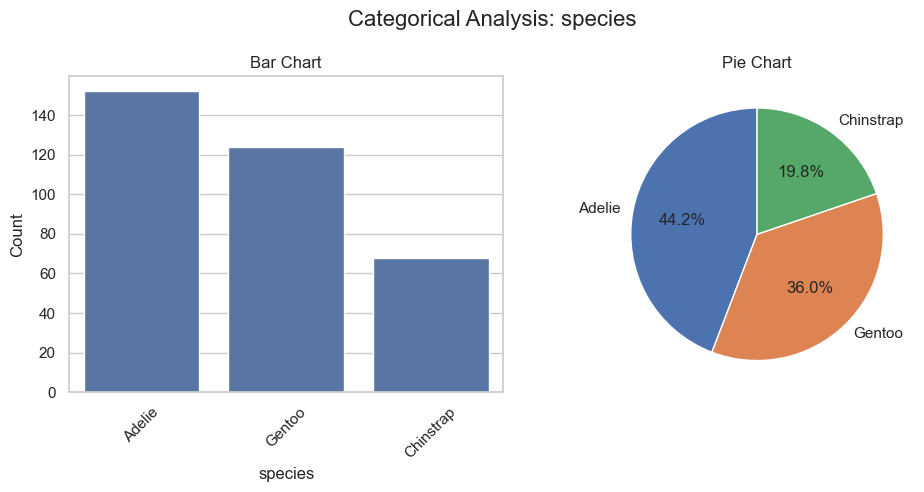

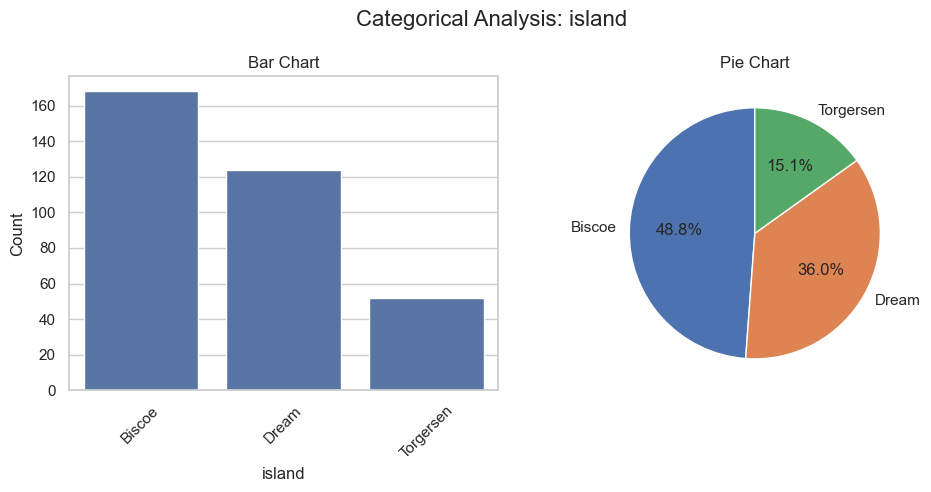

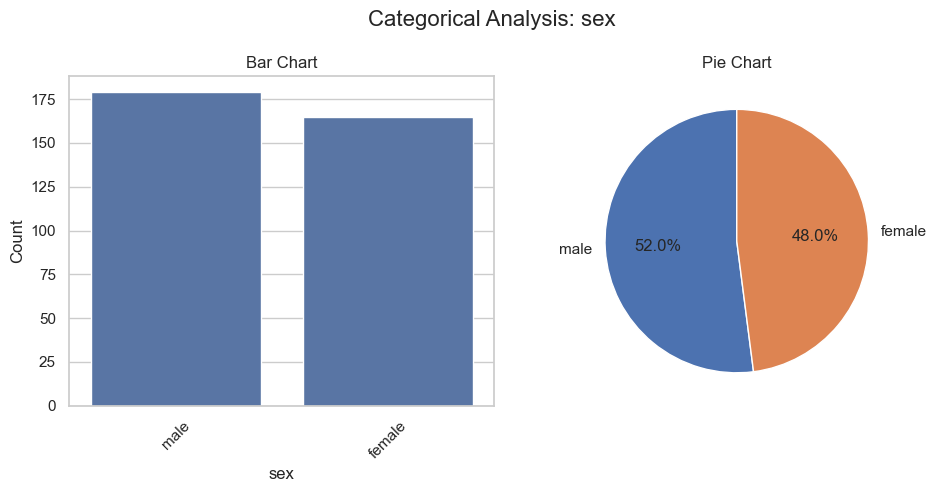

✅ Figures Loaded


In [633]:
print("a) Compute frequency counts, percentages, and mode for each category")

categorical_stats = []

for col in cat_cols:
    data = df[col]
    
    # Frequency counts
    freq = data.value_counts()
    
    # Percentages
    percent = data.value_counts(normalize=True) * 100
    
    # Mode
    mode_category = data.mode().iloc[0] if not data.mode().empty else None
    
    # Store summary info
    stats_dict = {
        'Attribute': col,
        'Mode': mode_category,
        'Unique Categories': data.nunique()
    }
    categorical_stats.append(stats_dict)

categorical_df = pd.DataFrame(categorical_stats).set_index('Attribute')
print(f"\nCategorical Attributes Summary: \n{categorical_df}")

print("\n✅ Categorical Attributes for Each Feature Computed")
    
print("\nb) Plot bar chart and pie chart")

for col in cat_cols:
    data = df[col]
    freq = data.value_counts()
    
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    fig.suptitle(f'Categorical Analysis: {col}', fontsize=16)
    
    # Bar Chart
    sns.countplot(x=data, order=freq.index, ax=axes[0])
    axes[0].set_title("Bar Chart")
    axes[0].set_ylabel("Count")
    axes[0].tick_params(axis='x', rotation=45)
    
    # Pie Chart
    axes[1].pie(freq, labels=freq.index, autopct='%1.1f%%', startangle=90)
    axes[1].set_title("Pie Chart")
    
    plt.tight_layout()
    plt.show()

print("✅ Figures Loaded")

### 7.3 Summary tables

In [646]:
print("a) One summary table for numerical key stats (compact but informative)")

numerical_summary = []

for col in num_cols:
    data = df[col].dropna()
    
    numerical_summary.append({
        'Attribute': col,
        'Mean': data.mean(),
        'Std': data.std(),
        'Min': data.min(),
        'Q1': data.quantile(0.25),
        'Median': data.median(),
        'Q3': data.quantile(0.75),
        'Max': data.max(),
        'Skewness': data.skew()
    })

numerical_summary_df = (
    pd.DataFrame(numerical_summary)
    .set_index('Attribute')
    .round(3)
)

print(f"\nNumerical Summary Table: \n{numerical_summary_df}")

print("\n✅ Numerical Summary Table Loaded")

print("\nb) One summary table for categorical distributions")

categorical_summary = {}

for col in cat_cols:
    freq_percent = (
        df[col]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    )
    
    categorical_summary[col] = freq_percent

categorical_summary_df = pd.concat(categorical_summary, axis=1).fillna(0)

print(f"\nCategorical Distribution Summary (%): \n{categorical_summary_df}")

print("\n✅ Categorical Summary Table Loaded")

a) One summary table for numerical key stats (compact but informative)

Numerical Summary Table: 
                       Mean      Std     Min        Q1   Median      Q3  \
Attribute                                                                 
bill_length_mm       43.925    5.444    32.1    39.275    44.45    48.5   
bill_depth_mm        17.152    1.969    13.1    15.600    17.30    18.7   
flipper_length_mm   200.892   14.024   172.0   190.000   197.00   213.0   
body_mass_g        4200.872  799.697  2700.0  3550.000  4050.00  4750.0   

                      Max  Skewness  
Attribute                            
bill_length_mm       59.6     0.052  
bill_depth_mm        21.5    -0.145  
flipper_length_mm   231.0     0.351  
body_mass_g        6300.0     0.475  

✅ Numerical Summary Table Loaded

b) One summary table for categorical distributions

Categorical Distribution Summary (%): 
           species  island    sex
Adelie       44.19    0.00   0.00
Gentoo       36.05    0.00   

## Section 8: Bivariate Analysis

### 8.1 Numerical vs Numerical (3 required pairs)


=== bill_length_mm vs bill_depth_mm =====
Correlation: -0.2350
Covariance:  -2.5190


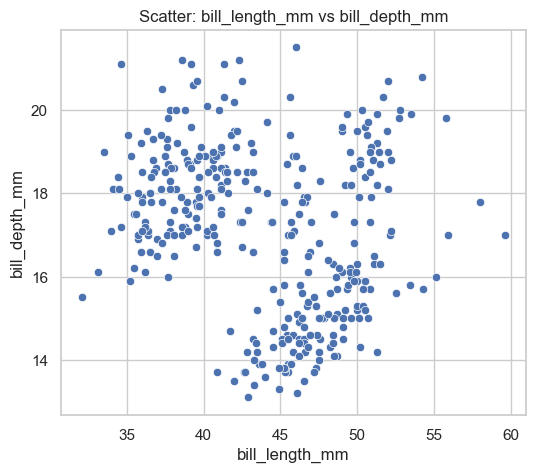


=== flipper_length_mm vs body_mass_g =====
Correlation: 0.8712
Covariance:  9770.5751


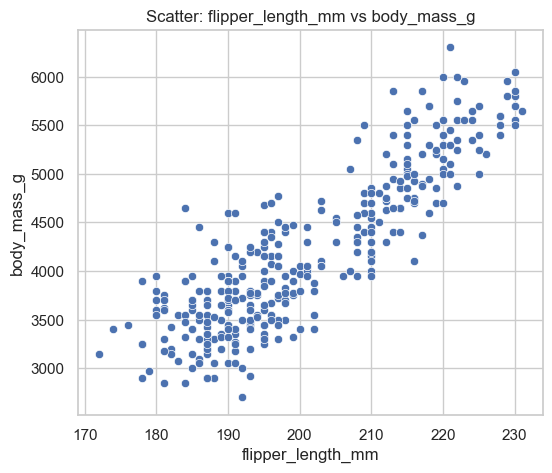


=== bill_length_mm vs flipper_length_mm =====
Correlation: 0.6559
Covariance:  50.0700


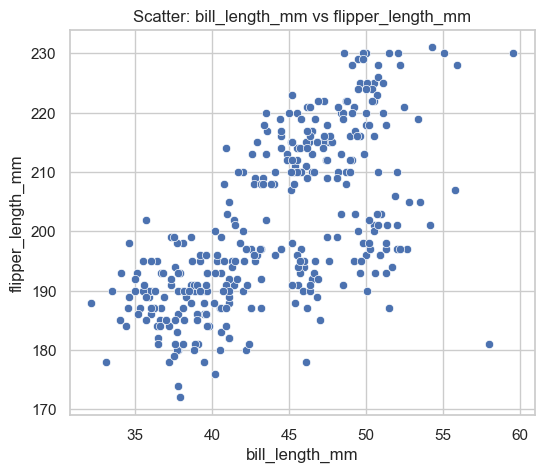


Numerical Pair Summary:


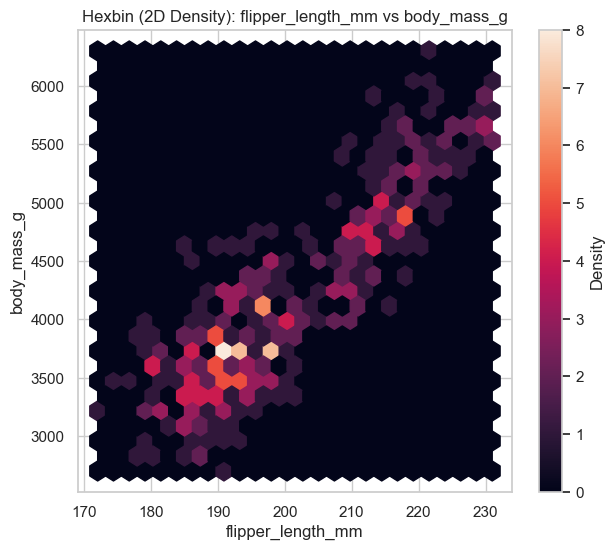

In [654]:
pairs = [
    ("bill_length_mm", "bill_depth_mm"),
    ("flipper_length_mm", "body_mass_g"),
    ("bill_length_mm", "flipper_length_mm")
]

results = []

for x_col, y_col in pairs:
    data = df[[x_col, y_col]]
    
    # Correlation (Pearson)
    corr = data[x_col].corr(data[y_col])
    
    # Covariance
    cov = data[x_col].cov(data[y_col])
    
    results.append({
        "Pair": f"{x_col} vs {y_col}",
        "Correlation": corr,
        "Covariance": cov
    })
    
    print(f"\n=== {x_col} vs {y_col} =====")
    print(f"Correlation: {corr:.4f}")
    print(f"Covariance:  {cov:.4f}")
    
    # Scatter plot
    plt.figure(figsize=(6,5))
    sns.scatterplot(x=data[x_col], y=data[y_col])
    plt.title(f"Scatter: {x_col} vs {y_col}")
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.show()

# Summary table
pair_results_df = pd.DataFrame(results).set_index("Pair").round(4)
print("\nNumerical Pair Summary:")
pair_results_df

# Identify most correlated pair (by absolute value)
most_corr_pair = max(results, key=lambda x: abs(x["Correlation"]))
pair_name = most_corr_pair["Pair"]

x_col, y_col = pair_name.split(" vs ")

data = df[[x_col, y_col]].dropna()

plt.figure(figsize=(7,6))
plt.hexbin(data[x_col], data[y_col], gridsize=25)
plt.colorbar(label="Density")
plt.title(f"Hexbin (2D Density): {x_col} vs {y_col}")
plt.xlabel(x_col)
plt.ylabel(y_col)
plt.show()


### 8.2 Numerical vs Categorical


Categorical Attribute: species


--- bill_length_mm grouped by species ---
             mean  median    std
species                         
Adelie     38.829   38.80  2.694
Chinstrap  48.834   49.55  3.339
Gentoo     47.480   47.25  3.082


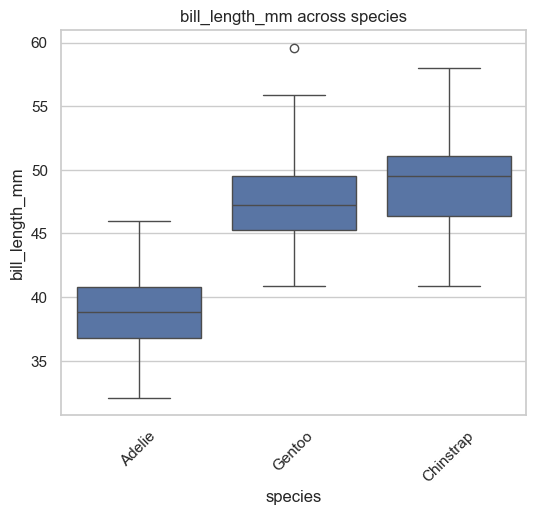


--- bill_depth_mm grouped by species ---
             mean  median    std
species                         
Adelie     18.339   18.40  1.216
Chinstrap  18.421   18.45  1.135
Gentoo     15.001   15.00  0.999


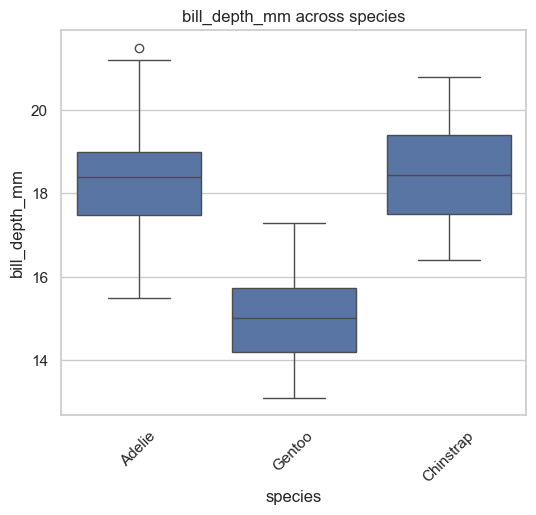


--- flipper_length_mm grouped by species ---
              mean  median    std
species                          
Adelie     190.000   190.0  6.543
Chinstrap  195.824   196.0  7.132
Gentoo     217.024   216.0  6.708


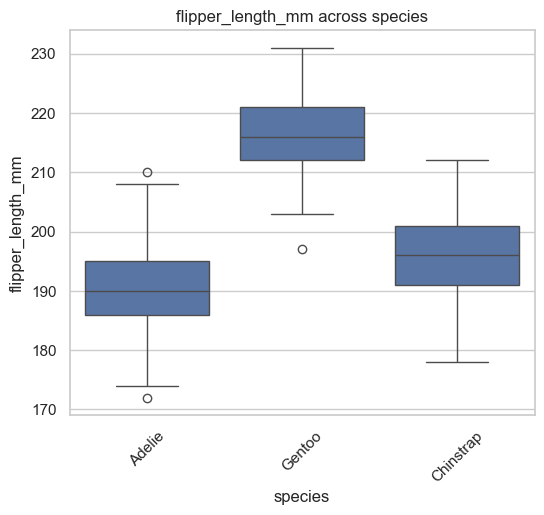


--- body_mass_g grouped by species ---
               mean  median      std
species                             
Adelie     3702.961  3700.0  457.923
Chinstrap  3733.088  3700.0  384.335
Gentoo     5067.742  5000.0  510.447


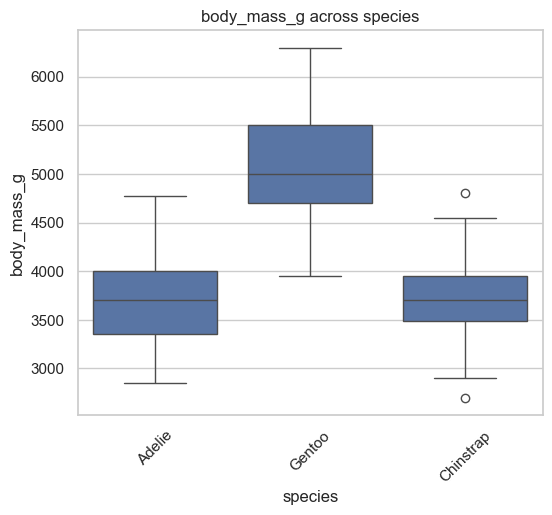


Categorical Attribute: island


--- bill_length_mm grouped by island ---
             mean  median    std
island                          
Biscoe     45.253   45.80  4.759
Dream      44.168   44.65  5.954
Torgersen  39.057   38.95  3.091


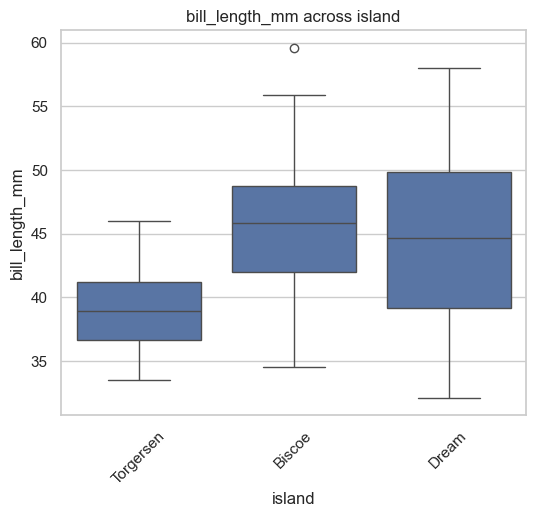


--- bill_depth_mm grouped by island ---
             mean  median    std
island                          
Biscoe     15.883   15.55  1.819
Dream      18.344   18.40  1.133
Torgersen  18.408   18.35  1.335


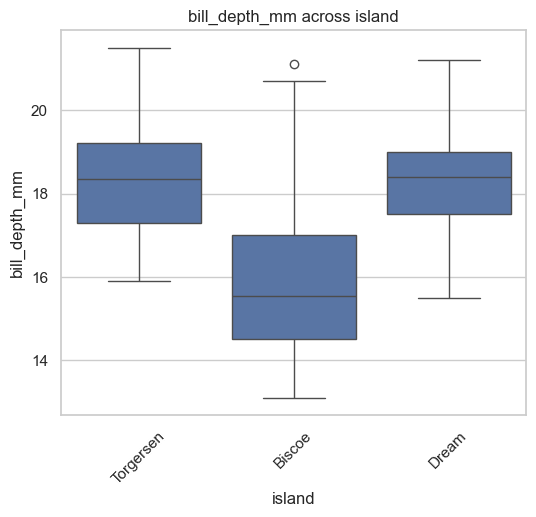


--- flipper_length_mm grouped by island ---
              mean  median     std
island                            
Biscoe     209.631   214.0  14.134
Dream      193.073   193.0   7.507
Torgersen  191.308   191.0   6.223


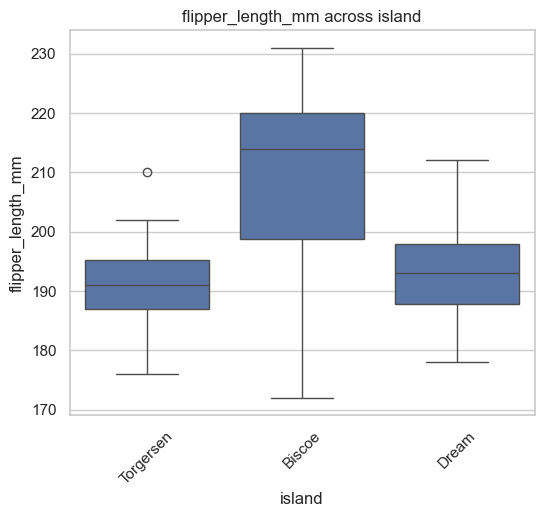


--- body_mass_g grouped by island ---
               mean  median      std
island                              
Biscoe     4712.054  4762.5  782.198
Dream      3712.903  3687.5  416.644
Torgersen  3712.981  3700.0  443.291


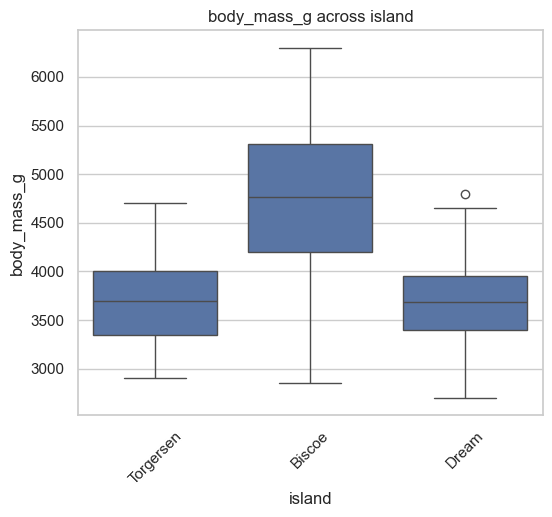


Categorical Attribute: sex


--- bill_length_mm grouped by sex ---
          mean  median    std
sex                          
female  42.097    42.8  4.903
male    45.610    46.2  5.385


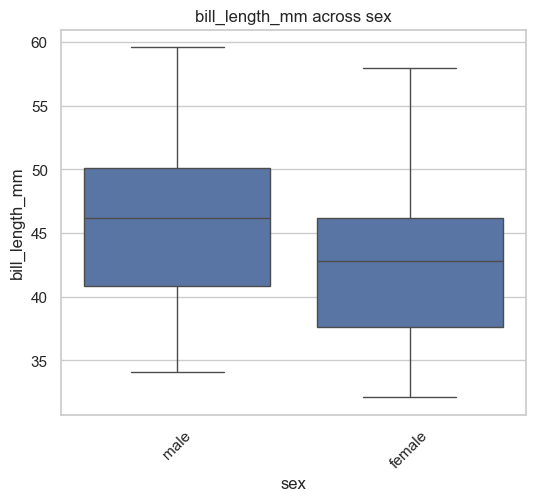


--- bill_depth_mm grouped by sex ---
          mean  median    std
sex                          
female  16.425    17.0  1.796
male    17.822    18.3  1.887


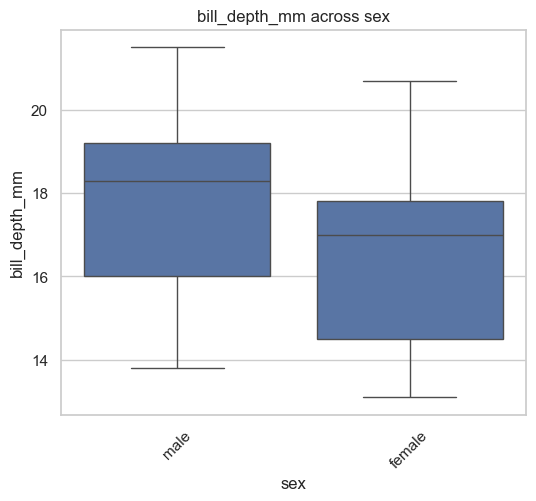


--- flipper_length_mm grouped by sex ---
           mean  median     std
sex                            
female  197.364   193.0  12.501
male    204.145   200.0  14.588


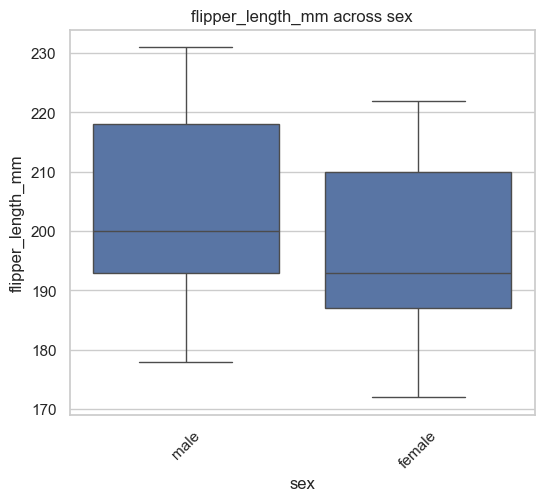


--- body_mass_g grouped by sex ---
            mean  median      std
sex                              
female  3862.273  3650.0  666.172
male    4512.989  4300.0  786.894


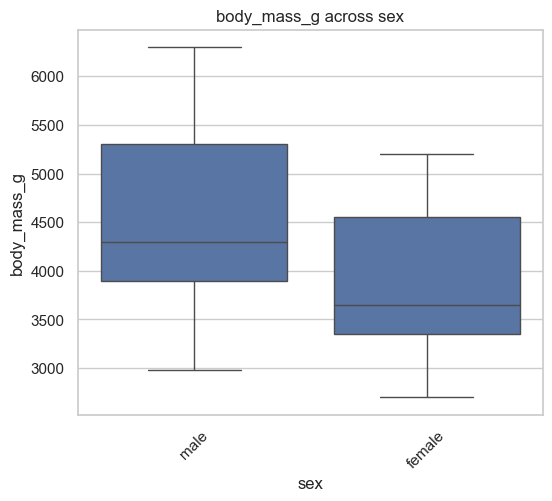

In [664]:
categorical_vars = ["species", "island", "sex"]

for cat in categorical_vars:
    print(f"\n==============================")
    print(f"Categorical Attribute: {cat}")
    print(f"==============================\n")
    
    for num in num_cols:
        data = df[[cat, num]]
        
        # Group-wise statistics
        group_stats = (
            data.groupby(cat)[num]
            .agg(['mean', 'median', 'std'])
            .round(3)
        )
        
        print(f"\n--- {num} grouped by {cat} ---")
        print(group_stats)
        
        # Box plot
        plt.figure(figsize=(6,5))
        sns.boxplot(x=cat, y=num, data=data)
        plt.title(f"{num} across {cat}")
        plt.xticks(rotation=45)
        plt.show()


#### c) short interpretation: which categories differ most?
The species category differs the most among all categorical attributes.